# SWOT L2 LR SSH Unsmoothed Data Analysis

**File:** SWOT_L2_LR_SSH_Unsmoothed_032_161_20250503T180245_20250503T185412_PIC2_01.nc

This notebook provides a comprehensive analysis of the SWOT Level-2 SSH Unsmoothed (250m posting) data, including:
1. File structure and metadata exploration
2. Variable information and statistics
3. Visualization on a map
4. Cross-swath bias correction

**Disclaimer:** The unsmoothed product lacks comprehensive error corrections found in Basic/Expert products. The cross-swath bias correction applied here is ad hoc and may introduce errors in coastal/inland waters.

## Cell 1: Import Required Libraries

In [68]:
# Import required libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## Cell 2: Load the NetCDF File

In [69]:
# Define the file path
nc_file = r"C:\Users\abhik\Desktop\project related work\SWOT_L2_LR_SSH_Unsmoothed_009_230_20240112T075548_20240112T084715_PGC0_02.nc"

# IMPORTANT: SWOT Unsmoothed data is stored in groups (left and right swaths)
# The root level only contains global attributes, no data variables!

# Load global attributes from root
ds_root = xr.open_dataset(nc_file)

# Load left and right swath data from their respective groups
ds_left = xr.open_dataset(nc_file, group='left', engine='netcdf4')
ds_right = xr.open_dataset(nc_file, group='right', engine='netcdf4')

print("File loaded successfully!")
print(f"File: {nc_file.split(chr(92))[-1]}")
print(f"\n✓ Root dataset (global attributes only)")
print(f"✓ Left swath data loaded: {len(ds_left.data_vars)} variables")
print(f"✓ Right swath data loaded: {len(ds_right.data_vars)} variables")

File loaded successfully!
File: SWOT_L2_LR_SSH_Unsmoothed_009_230_20240112T075548_20240112T084715_PGC0_02.nc

✓ Root dataset (global attributes only)
✓ Left swath data loaded: 16 variables
✓ Right swath data loaded: 16 variables


## Cell 3: Global Attributes (File Metadata)

In [70]:
# Display global attributes from root dataset
print("=" * 80)
print("GLOBAL ATTRIBUTES (File Metadata)")
print("=" * 80)

for attr_name, attr_value in ds_root.attrs.items():
    print(f"\n{attr_name}:")
    print(f"    {attr_value}")

GLOBAL ATTRIBUTES (File Metadata)

Conventions:
    CF-1.7

title:
    Level 2 Low Rate Sea Surface Height Data Product - Unsmoothed

institution:
    JPL

source:
    Ka-band radar interferometer

history:
    2024-05-08T05:16:50Z : Creation

platform:
    SWOT

reference_document:
    D-56407_SWOT_Product_Description_L2_LR_SSH

contact:
    podaac@jpl.nasa.gov

cycle_number:
    9

pass_number:
    230

equator_time:
    2024-01-12T08:21:29.832000Z

short_name:
    L2_LR_SSH

product_file_id:
    Unsmoothed

crid:
    PGC0

product_version:
    02

pge_name:
    PGE_L2_LR_SSH

pge_version:
    5.0.2

time_coverage_start:
    2024-01-12T07:55:48.356268

time_coverage_end:
    2024-01-12T08:47:15.214830

geospatial_lon_min:
    12.207575

geospatial_lon_max:
    179.24678899999998

geospatial_lat_min:
    -77.618764

geospatial_lat_max:
    78.24800599999999

left_first_longitude:
    9.969209968386869e+36

left_first_latitude:
    9.969209968386869e+36

left_last_longitude:
    9.9692

## Cell 4: Dimensions Information

In [71]:
# Display dimensions for both swaths
print("=" * 80)
print("DIMENSIONS")
print("=" * 80)

print("\n--- LEFT SWATH ---")
for dim_name, dim_size in ds_left.dims.items():
    print(f"  {dim_name}: {dim_size}")

print("\n--- RIGHT SWATH ---")
for dim_name, dim_size in ds_right.dims.items():
    print(f"  {dim_name}: {dim_size}")

print(f"\nNote: num_lines = along-track direction, num_pixels = cross-track direction")

DIMENSIONS

--- LEFT SWATH ---
  num_lines: 83017
  num_pixels: 240

--- RIGHT SWATH ---
  num_lines: 83017
  num_pixels: 240

Note: num_lines = along-track direction, num_pixels = cross-track direction


## Cell 5: Coordinates Information

In [72]:
# Display coordinates from left swath (same structure for right)
print("=" * 80)
print("COORDINATES (from left swath)")
print("=" * 80)

for coord_name in ds_left.coords:
    coord = ds_left.coords[coord_name]
    print(f"\n{coord_name}:")
    print(f"    Shape: {coord.shape}")
    print(f"    Dtype: {coord.dtype}")
    if coord.attrs:
        for attr_name, attr_value in list(coord.attrs.items())[:5]:  # Show first 5 attributes
            print(f"    {attr_name}: {attr_value}")

COORDINATES (from left swath)

latitude:
    Shape: (83017, 240)
    Dtype: float64
    long_name: latitude (positive N, negative S)
    standard_name: latitude
    units: degrees_north
    quality_flag: ssh_karin_2_qual
    valid_min: -80000000

longitude:
    Shape: (83017, 240)
    Dtype: float64
    long_name: longitude (degrees East)
    standard_name: longitude
    units: degrees_east
    quality_flag: ssh_karin_2_qual
    valid_min: 0


## Cell 6: All Data Variables - Summary

In [73]:
# Display all data variables for both swaths
print("=" * 80)
print("DATA VARIABLES SUMMARY")
print("=" * 80)

var_info = []
for var_name in ds_left.data_vars:
    var = ds_left[var_name]
    var_info.append({
        'Variable': var_name,
        'Shape': str(var.shape),
        'Dtype': str(var.dtype),
        'Swath': 'both'
    })

df_vars = pd.DataFrame(var_info)
print(f"\nTotal number of variables per swath: {len(ds_left.data_vars)}")
print("(Same variables available in both left and right swaths)\n")
display(df_vars)

DATA VARIABLES SUMMARY

Total number of variables per swath: 16
(Same variables available in both left and right swaths)



,Variable,Shape,Dtype,Swath
0,time,"(83017,)",datetime64[ns],both
1,time_tai,"(83017,)",datetime64[ns],both
2,latitude_uncert,"(83017, 240)",float64,both
3,longitude_uncert,"(83017, 240)",float64,both
4,polarization_karin,"(83017,)",object,both
5,ssh_karin_2,"(83017, 240)",float64,both
6,ssh_karin_2_qual,"(83017, 240)",float64,both
7,ssh_karin_uncert,"(83017, 240)",float64,both
8,sig0_karin_2,"(83017, 240)",float32,both
9,sig0_karin_2_qual,"(83017, 240)",float64,both


## Cell 7: Detailed Variable Information with Attributes

In [74]:
# Display detailed variable information
print("=" * 80)
print("DETAILED VARIABLE INFORMATION (Left Swath)")
print("=" * 80)

for var_name in list(ds_left.data_vars)[:10]:  # Show first 10 variables
    var = ds_left[var_name]
    print(f"\n{'='*60}")
    print(f"Variable: {var_name}")
    print(f"{'='*60}")
    print(f"  Shape: {var.shape}")
    print(f"  Dtype: {var.dtype}")
    print(f"  Dimensions: {var.dims}")
    
    # Print key attributes
    if var.attrs:
        print(f"  Attributes:")
        for attr_name in ['long_name', 'units', 'valid_min', 'valid_max']:
            if attr_name in var.attrs:
                print(f"    - {attr_name}: {var.attrs[attr_name]}")

DETAILED VARIABLE INFORMATION (Left Swath)

Variable: time
  Shape: (83017,)
  Dtype: datetime64[ns]
  Dimensions: ('num_lines',)
  Attributes:
    - long_name: time in UTC

Variable: time_tai
  Shape: (83017,)
  Dtype: datetime64[ns]
  Dimensions: ('num_lines',)
  Attributes:
    - long_name: time in TAI

Variable: latitude_uncert
  Shape: (83017, 240)
  Dtype: float64
  Dimensions: ('num_lines', 'num_pixels')
  Attributes:
    - long_name: 1-sigma latitude uncertainty
    - units: degrees
    - valid_min: 0
    - valid_max: 20000

Variable: longitude_uncert
  Shape: (83017, 240)
  Dtype: float64
  Dimensions: ('num_lines', 'num_pixels')
  Attributes:
    - long_name: 1-sigma longitude uncertainty
    - units: degrees
    - valid_min: 0
    - valid_max: 20000

Variable: polarization_karin
  Shape: (83017,)
  Dtype: object
  Dimensions: ('num_lines',)
  Attributes:
    - long_name: polarization for each side of the KaRIn swath

Variable: ssh_karin_2
  Shape: (83017, 240)
  Dtype: float

## Cell 8: Key Variable Statistics

In [75]:
# Display statistics for key variables from both swaths
print("=" * 80)
print("KEY VARIABLE STATISTICS")
print("=" * 80)

key_vars = ['ssh_karin_2', 'sig0_karin_2']

for swath_name, ds_swath in [('LEFT', ds_left), ('RIGHT', ds_right)]:
    print(f"\n--- {swath_name} SWATH ---")
    
    # Latitude and Longitude from coordinates
    lat = ds_swath.coords['latitude'].values
    lon = ds_swath.coords['longitude'].values
    
    print(f"\nlatitude:")
    print(f"  Range: {np.nanmin(lat):.4f}° to {np.nanmax(lat):.4f}°")
    print(f"  Valid: {np.sum(~np.isnan(lat))} / {lat.size}")
    
    print(f"\nlongitude:")
    print(f"  Range: {np.nanmin(lon):.4f}° to {np.nanmax(lon):.4f}°")
    print(f"  Valid: {np.sum(~np.isnan(lon))} / {lon.size}")
    
    for var_name in key_vars:
        if var_name in ds_swath:
            data = ds_swath[var_name].values.flatten()
            valid_data = data[~np.isnan(data)]
            print(f"\n{var_name}:")
            print(f"  Min: {np.nanmin(data):.4f}, Max: {np.nanmax(data):.4f}")
            print(f"  Mean: {np.nanmean(data):.4f}, Std: {np.nanstd(data):.4f}")
            print(f"  Valid: {len(valid_data)} / {len(data)} ({100*len(valid_data)/len(data):.1f}%)")

KEY VARIABLE STATISTICS

--- LEFT SWATH ---

latitude:
  Range: -77.6188° to 78.2480°
  Valid: 19402050 / 19924080

longitude:
  Range: 12.2076° to 179.2468°
  Valid: 19402050 / 19924080

ssh_karin_2:
  Min: -260.4554, Max: 5681.9475
  Mean: 610.5850, Std: 1337.2105
  Valid: 19402050 / 19924080 (97.4%)

sig0_karin_2:
  Min: -996.6771, Max: 31168.1895
  Mean: 19.4972, Std: 45.2941
  Valid: 19402048 / 19924080 (97.4%)

--- RIGHT SWATH ---

latitude:
  Range: -78.2458° to 77.6213°
  Valid: 19399138 / 19924080

longitude:
  Range: 12.2097° to 179.2485°
  Valid: 19399138 / 19924080

ssh_karin_2:
  Min: -102.7414, Max: 5684.4159
  Mean: 609.8541, Std: 1337.3472
  Valid: 19399138 / 19924080 (97.4%)

sig0_karin_2:
  Min: -754.0170, Max: 45109.8555
  Mean: 19.3352, Std: 46.4573
  Valid: 19396601 / 19924080 (97.4%)


## Cell 9: Geographic Coverage

In [76]:
# Display geographic coverage for both swaths
print("=" * 80)
print("GEOGRAPHIC COVERAGE")
print("=" * 80)

for swath_name, ds_swath in [('LEFT', ds_left), ('RIGHT', ds_right)]:
    lat = ds_swath.coords['latitude'].values
    lon = ds_swath.coords['longitude'].values
    
    print(f"\n--- {swath_name} SWATH ---")
    print(f"  Latitude Range: {np.nanmin(lat):.4f}° to {np.nanmax(lat):.4f}°")
    print(f"  Longitude Range: {np.nanmin(lon):.4f}° to {np.nanmax(lon):.4f}°")
    print(f"  Grid Shape: {lat.shape} (num_lines × num_pixels)")

# Combined coverage
all_lat = np.concatenate([ds_left.coords['latitude'].values.flatten(), 
                          ds_right.coords['latitude'].values.flatten()])
all_lon = np.concatenate([ds_left.coords['longitude'].values.flatten(), 
                          ds_right.coords['longitude'].values.flatten()])
print(f"\n--- COMBINED COVERAGE ---")
print(f"  Latitude Range: {np.nanmin(all_lat):.4f}° to {np.nanmax(all_lat):.4f}°")
print(f"  Longitude Range: {np.nanmin(all_lon):.4f}° to {np.nanmax(all_lon):.4f}°")

GEOGRAPHIC COVERAGE

--- LEFT SWATH ---
  Latitude Range: -77.6188° to 78.2480°
  Longitude Range: 12.2076° to 179.2468°
  Grid Shape: (83017, 240) (num_lines × num_pixels)

--- RIGHT SWATH ---
  Latitude Range: -78.2458° to 77.6213°
  Longitude Range: 12.2097° to 179.2485°
  Grid Shape: (83017, 240) (num_lines × num_pixels)

--- COMBINED COVERAGE ---
  Latitude Range: -78.2458° to 78.2480°
  Longitude Range: 12.2076° to 179.2485°


## Cell 10: Time Information

In [77]:
# Display time information
print("=" * 80)
print("TIME INFORMATION")
print("=" * 80)

if 'time' in ds_left:
    time_var = ds_left['time'].values
    print(f"\nTime variable shape: {time_var.shape}")
    print(f"Start time: {time_var[0]}")
    print(f"End time: {time_var[-1]}")
    print(f"Duration: {(time_var[-1] - time_var[0]).astype('timedelta64[m]')} minutes")
else:
    print("No time variable found in swath data")

# Also show from global attributes
print(f"\nFrom global attributes:")
print(f"  Time coverage start: {ds_root.attrs.get('time_coverage_start', 'N/A')}")
print(f"  Time coverage end: {ds_root.attrs.get('time_coverage_end', 'N/A')}")
print(f"  Cycle number: {ds_root.attrs.get('cycle_number', 'N/A')}")
print(f"  Pass number: {ds_root.attrs.get('pass_number', 'N/A')}")

TIME INFORMATION

Time variable shape: (83017,)
Start time: 2024-01-12T07:55:48.356268416
End time: 2024-01-12T08:47:15.214830336
Duration: 51 minutes minutes

From global attributes:
  Time coverage start: 2024-01-12T07:55:48.356268
  Time coverage end: 2024-01-12T08:47:15.214830
  Cycle number: 9
  Pass number: 230


## Cell 11: Dataset Overview

In [78]:
# Print the complete dataset overview
print("=" * 80)
print("COMPLETE DATASET OVERVIEW - LEFT SWATH")
print("=" * 80)
print(ds_left)

print("\n" + "=" * 80)
print("COMPLETE DATASET OVERVIEW - RIGHT SWATH")
print("=" * 80)
print(ds_right)

COMPLETE DATASET OVERVIEW - LEFT SWATH
<xarray.Dataset> Size: 2GB
Dimensions:                                (num_lines: 83017, num_pixels: 240)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 159MB ...
    longitude                              (num_lines, num_pixels) float64 159MB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/16)
    time                                   (num_lines) datetime64[ns] 664kB 2...
    time_tai                               (num_lines) datetime64[ns] 664kB ...
    latitude_uncert                        (num_lines, num_pixels) float64 159MB ...
    longitude_uncert                       (num_lines, num_pixels) float64 159MB ...
    polarization_karin                     (num_lines) object 664kB ...
    ssh_karin_2                            (num_lines, num_pixels) float64 159MB ...
    ...                                     ...
    sig0_karin_uncert                      (num_lines, num

---
# Part 2: Visualization

## Cell 12: Import Visualization Libraries

In [79]:
# Import visualization libraries
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("Cartopy imported successfully!")

Cartopy imported successfully!


## Cell 13: Plot Raw SSH Data (Before Correction)

Plotting raw SSH data - Ocean Only (Andaman Sea Region)...
  Left swath: 1618819 ocean data points in region
  Right swath: 1659457 ocean data points in region


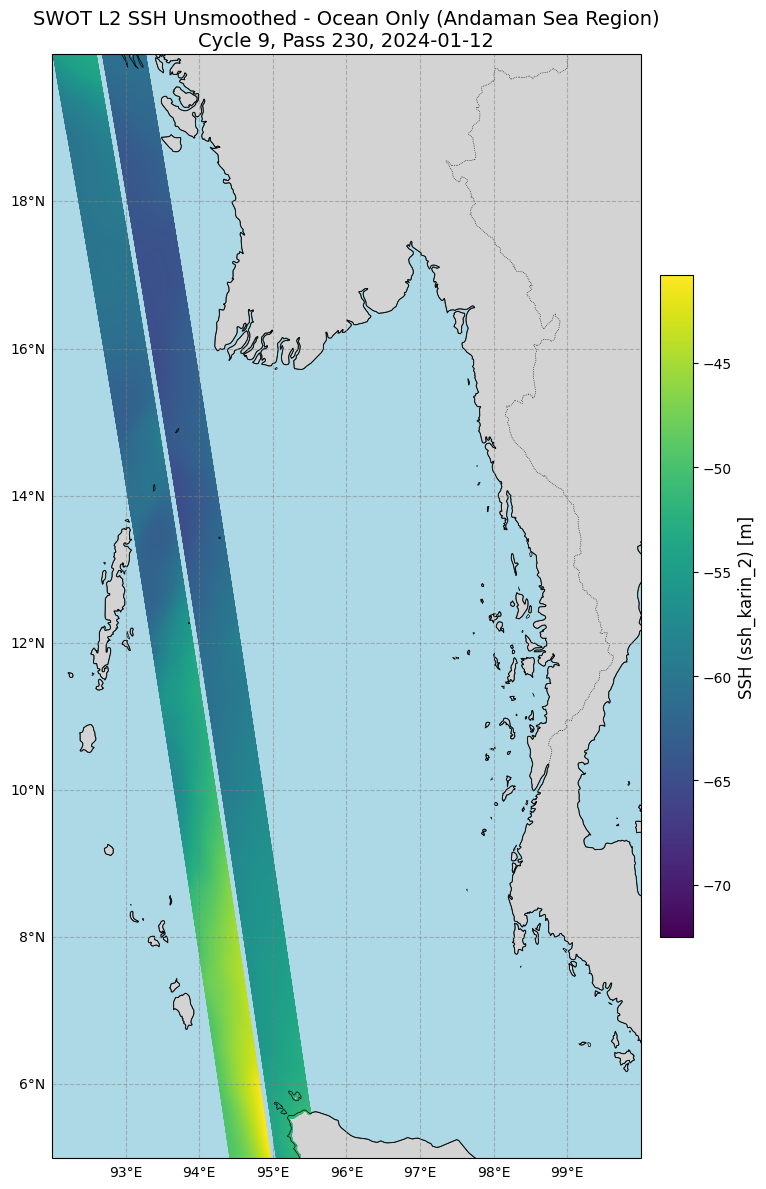

In [80]:
# Plot raw SSH data - OCEAN ONLY for Andaman Sea Region
print("Plotting raw SSH data - Ocean Only (Andaman Sea Region)...")

# Define Andaman Sea region bounds
# Latitude: ~5°N to ~20°N, Longitude: ~92°E to ~100°E
ANDAMAN_LAT_MIN, ANDAMAN_LAT_MAX = 5.0, 20.0
ANDAMAN_LON_MIN, ANDAMAN_LON_MAX = 92.0, 100.0

# Create figure
fig, ax = plt.subplots(figsize=(10, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Collect data for plotting
has_data = False

# Plot both swaths - OCEAN ONLY
for swath_name, ds_swath in [('left', ds_left), ('right', ds_right)]:
    lat = ds_swath.coords['latitude'].values
    lon = ds_swath.coords['longitude'].values
    ssh = ds_swath['ssh_karin_2'].values
    
    # Get surface classification flag (0 = open ocean)
    if 'ancillary_surface_classification_flag' in ds_swath:
        surf_flag = ds_swath['ancillary_surface_classification_flag'].values
        ocean_mask = (surf_flag == 0)  # 0 = open ocean
    else:
        ocean_mask = np.ones_like(ssh, dtype=bool)
    
    # Create regional mask for Andaman Sea
    region_mask = (lat >= ANDAMAN_LAT_MIN) & (lat <= ANDAMAN_LAT_MAX) & \
                  (lon >= ANDAMAN_LON_MIN) & (lon <= ANDAMAN_LON_MAX)
    
    # Combine masks: valid data + ocean only + regional
    valid_mask = ~np.isnan(lon + lat + ssh)
    combined_mask = valid_mask & ocean_mask & region_mask
    
    # Check if there's data in this region
    if np.sum(combined_mask) > 0:
        has_data = True
        # Plot SSH data - ocean only
        cax = ax.scatter(lon[combined_mask], lat[combined_mask], 
                         c=ssh[combined_mask], s=0.5, 
                         cmap='viridis', 
                         transform=ccrs.PlateCarree())
        print(f"  {swath_name.capitalize()} swath: {np.sum(combined_mask)} ocean data points in region")

if has_data:
    # Add colorbar
    cbar = plt.colorbar(cax, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('SSH (ssh_karin_2) [m]', fontsize=12)

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    gl.right_labels = False
    gl.top_labels = False

    # Set extent to Andaman Sea region
    ax.set_extent([ANDAMAN_LON_MIN, ANDAMAN_LON_MAX, ANDAMAN_LAT_MIN, ANDAMAN_LAT_MAX], crs=ccrs.PlateCarree())

    # Title
    ax.set_title(f'SWOT L2 SSH Unsmoothed - Ocean Only (Andaman Sea Region)\n'
                 f'Cycle {ds_root.attrs.get("cycle_number")}, Pass {ds_root.attrs.get("pass_number")}, '
                 f'{ds_root.attrs.get("time_coverage_start", "")[:10]}', fontsize=14)

    plt.tight_layout()
    plt.show()
else:
    plt.close()
    print("\n⚠️ No ocean data found in Andaman Sea region for this pass!")
    print(f"   Region bounds: Lat {ANDAMAN_LAT_MIN}°-{ANDAMAN_LAT_MAX}°N, Lon {ANDAMAN_LON_MIN}°-{ANDAMAN_LON_MAX}°E")
    print("\n   This pass may not cover this region. Checking data coverage...")

---
# Part 3: Cross-Swath Bias Correction

## Cell 14: Define Cross-Swath Correction Function

In [81]:
def apply_cross_swath_correction(ds_swath, lat_bounds=None, lon_bounds=None, ocean_only=True):
    """
    Apply cross-swath bias correction to SSH data from a SWOT swath.
    
    This is an ad hoc approach that:
    1. Masks non-ocean data using surface classification flag
    2. Filters by geographic region if bounds provided
    3. Removes the minimum value to reduce bias
    4. Removes the along-track mean for each cross-track position
    
    Parameters:
    -----------
    ds_swath : xarray.Dataset
        SWOT swath dataset (left or right)
    lat_bounds : tuple, optional
        (lat_min, lat_max) for selecting region
    lon_bounds : tuple, optional
        (lon_min, lon_max) for selecting region
    ocean_only : bool, default True
        If True, mask non-ocean data using surface classification flag
        
    Returns:
    --------
    ssh_corrected : numpy.ndarray
        Corrected SSH data
    lat : numpy.ndarray
        Latitude array
    lon : numpy.ndarray
        Longitude array
    ocean_mask : numpy.ndarray
        Boolean mask for ocean data points
    region_mask : numpy.ndarray
        Boolean mask for regional data points
    """
    lat = ds_swath.coords['latitude'].values
    lon = ds_swath.coords['longitude'].values
    ssh = ds_swath['ssh_karin_2'].values
    
    # Create ocean mask using surface classification flag
    if ocean_only and 'ancillary_surface_classification_flag' in ds_swath:
        surf_flag = ds_swath['ancillary_surface_classification_flag'].values
        # Flag == 0 means open ocean
        ocean_mask = (surf_flag == 0)
        # Mask non-ocean data
        ssh_masked = np.where(ocean_mask, ssh, np.nan)
        print(f"    Ocean mask applied: {np.sum(ocean_mask)} ocean pixels")
    else:
        ocean_mask = ~np.isnan(ssh)
        ssh_masked = ssh.copy()
    
    # Create regional mask if bounds provided
    region_mask = np.ones_like(ssh, dtype=bool)
    if lat_bounds is not None:
        region_mask &= (lat >= lat_bounds[0]) & (lat <= lat_bounds[1])
    if lon_bounds is not None:
        region_mask &= (lon >= lon_bounds[0]) & (lon <= lon_bounds[1])
    
    # Combined mask for valid data
    valid_mask = ocean_mask & region_mask & ~np.isnan(ssh)
    
    # Check if we have valid data
    if np.sum(valid_mask) == 0:
        print("    ⚠️ No valid data in specified region!")
        return ssh_masked, lat, lon, ocean_mask, region_mask
    
    print(f"    Regional mask applied: {np.sum(valid_mask)} valid pixels")
    
    # Remove minimum (basic bias removal) - only from valid data
    ssh_min = np.nanmin(ssh_masked[valid_mask])
    ssh_corrected = ssh_masked - ssh_min
    
    # Define latitude mask for along-track mean calculation
    if lat_bounds is not None:
        ref_col = min(10, lat.shape[1] - 1)
        msk = (lat[:, ref_col] >= lat_bounds[0]) & (lat[:, ref_col] <= lat_bounds[1])
    else:
        msk = np.ones(lat.shape[0], dtype=bool)
    
    # Ensure we have data in the mask
    if np.sum(msk) == 0:
        msk = np.ones(lat.shape[0], dtype=bool)
    
    # Remove along-track mean for each cross-track position
    # This is the ad hoc cross-swath bias correction
    along_track_mean = np.nanmean(ssh_corrected[msk, :], axis=0)
    
    # Handle NaN values in along-track mean
    along_track_mean = np.where(np.isnan(along_track_mean), 0, along_track_mean)
    
    ssh_corrected = ssh_corrected - along_track_mean[np.newaxis, :]
    
    # Apply masks to keep only ocean data in region
    ssh_corrected = np.where(valid_mask, ssh_corrected, np.nan)
    
    return ssh_corrected, lat, lon, ocean_mask, region_mask

print("Cross-swath correction function defined!")
print("  - Supports ocean-only filtering")
print("  - Supports regional (lat/lon) bounds")
print("  - Returns masks for further analysis")

Cross-swath correction function defined!
  - Supports ocean-only filtering
  - Supports regional (lat/lon) bounds
  - Returns masks for further analysis


## Cell 15: Apply Cross-Swath Correction

In [82]:
# Apply cross-swath correction to both swaths - ANDAMAN SEA REGION, OCEAN ONLY
print("Applying cross-swath bias correction (Andaman Sea Region, Ocean Only)...")

# Define Andaman Sea region bounds
ANDAMAN_LAT_BOUNDS = (5.0, 20.0)   # Latitude: ~5°N to ~20°N
ANDAMAN_LON_BOUNDS = (92.0, 100.0)  # Longitude: ~92°E to ~100°E

print(f"\nRegion: Andaman Sea")
print(f"  Latitude bounds: {ANDAMAN_LAT_BOUNDS[0]}°N to {ANDAMAN_LAT_BOUNDS[1]}°N")
print(f"  Longitude bounds: {ANDAMAN_LON_BOUNDS[0]}°E to {ANDAMAN_LON_BOUNDS[1]}°E")

# Store corrected data for both swaths
corrected_data = {}
has_data = False

for swath_name, ds_swath in [('left', ds_left), ('right', ds_right)]:
    print(f"\n{swath_name.upper()} SWATH:")
    
    ssh_corr, lat_arr, lon_arr, ocean_mask, region_mask = apply_cross_swath_correction(
        ds_swath,
        lat_bounds=ANDAMAN_LAT_BOUNDS,
        lon_bounds=ANDAMAN_LON_BOUNDS,
        ocean_only=True
    )
    
    # Check if we have data in region
    valid_count = np.sum(~np.isnan(ssh_corr))
    if valid_count > 0:
        has_data = True
    
    corrected_data[swath_name] = {
        'ssh_corrected': ssh_corr,
        'lat': lat_arr,
        'lon': lon_arr,
        'ssh_raw': ds_swath['ssh_karin_2'].values,
        'ocean_mask': ocean_mask,
        'region_mask': region_mask
    }
    
    raw_ssh = ds_swath['ssh_karin_2'].values
    raw_in_region = np.where(region_mask & ocean_mask, raw_ssh, np.nan)
    
    print(f"    Original SSH range (in region): {np.nanmin(raw_in_region):.4f} to {np.nanmax(raw_in_region):.4f} m")
    print(f"    Corrected SSH range: {np.nanmin(ssh_corr):.4f} to {np.nanmax(ssh_corr):.4f} m")
    print(f"    Valid ocean pixels in region: {valid_count}")

if has_data:
    print("\n✓ Correction applied successfully!")
else:
    print("\n⚠️ No ocean data found in Andaman Sea region for this pass!")
    print("   This satellite pass may not cover this region.")

Applying cross-swath bias correction (Andaman Sea Region, Ocean Only)...

Region: Andaman Sea
  Latitude bounds: 5.0°N to 20.0°N
  Longitude bounds: 92.0°E to 100.0°E

LEFT SWATH:
    Ocean mask applied: 11809499 ocean pixels
    Regional mask applied: 1618819 valid pixels
    Original SSH range (in region): -75.6723 to -13.0673 m
    Corrected SSH range: -24.8122 to 37.4247 m
    Valid ocean pixels in region: 1618819

RIGHT SWATH:
    Ocean mask applied: 11582570 ocean pixels
    Regional mask applied: 1659457 valid pixels
    Original SSH range (in region): -72.5114 to -40.8012 m
    Corrected SSH range: -16.5207 to 12.7480 m
    Valid ocean pixels in region: 1659457

✓ Correction applied successfully!


## Cell 16: Plot Corrected SSH Data

Plotting corrected SSH data (Ocean Only - Andaman & Nicobar Region)...
  Left swath: 1618819 ocean data points plotted
  Right swath: 1659457 ocean data points plotted


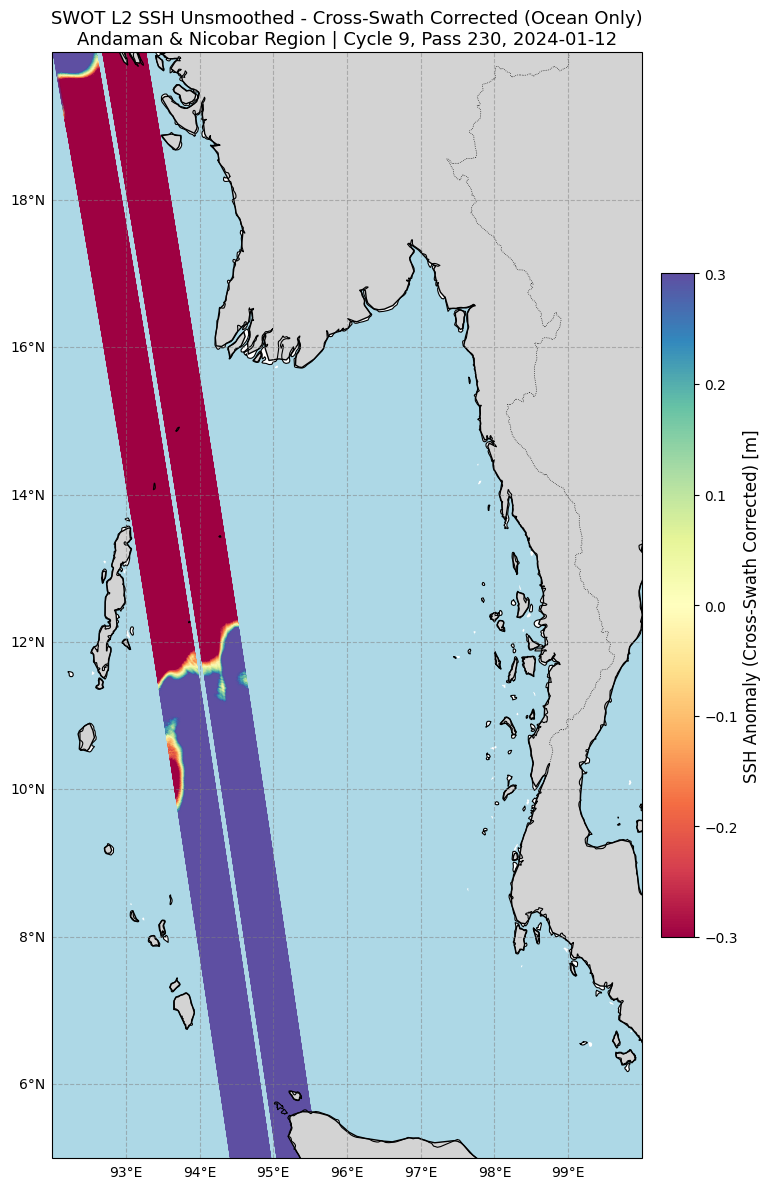

In [83]:
# Plot corrected SSH data - OCEAN ONLY for Andaman & Nicobar Region
print("Plotting corrected SSH data (Ocean Only - Andaman & Nicobar Region)...")

# Create figure
fig, ax = plt.subplots(figsize=(10, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))

# Add map features
land = cfeature.NaturalEarthFeature('physical', 'land', '50m', 
                                     edgecolor='black', facecolor='lightgray')
ax.add_feature(land)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Check if we have data
has_data = False

# Plot both swaths - ocean only, corrected
for swath_name in ['left', 'right']:
    data = corrected_data[swath_name]
    lat = data['lat']
    lon = data['lon']
    ssh_corr = data['ssh_corrected']
    
    # Valid data mask (already filtered for ocean and region)
    m = ~np.isnan(ssh_corr)
    
    if np.sum(m) > 0:
        has_data = True
        # Plot corrected SSH data
        cax = ax.scatter(lon[m], lat[m], 
                         c=ssh_corr[m], s=0.5, 
                         vmin=-0.3, vmax=0.3,
                         cmap=plt.cm.Spectral, 
                         transform=ccrs.PlateCarree())
        print(f"  {swath_name.capitalize()} swath: {np.sum(m)} ocean data points plotted")

if has_data:
    # Add colorbar
    cbar = plt.colorbar(cax, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('SSH Anomaly (Cross-Swath Corrected) [m]', fontsize=12)

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    gl.right_labels = False
    gl.top_labels = False

    # Set extent to Andaman & Nicobar region
    ax.set_extent([ANDAMAN_LON_BOUNDS[0], ANDAMAN_LON_BOUNDS[1], 
                   ANDAMAN_LAT_BOUNDS[0], ANDAMAN_LAT_BOUNDS[1]], crs=ccrs.PlateCarree())

    # Title
    ax.set_title(f'SWOT L2 SSH Unsmoothed - Cross-Swath Corrected (Ocean Only)\n'
                 f'Andaman & Nicobar Region | Cycle {ds_root.attrs.get("cycle_number")}, '
                 f'Pass {ds_root.attrs.get("pass_number")}, '
                 f'{ds_root.attrs.get("time_coverage_start", "")[:10]}', fontsize=13)

    plt.tight_layout()
    plt.show()
else:
    plt.close()
    print("\n⚠️ No corrected ocean data to plot in Andaman & Nicobar region!")

## Cell 17: Side-by-Side Comparison

Creating side-by-side comparison (Ocean Only - Andaman & Nicobar Region)...


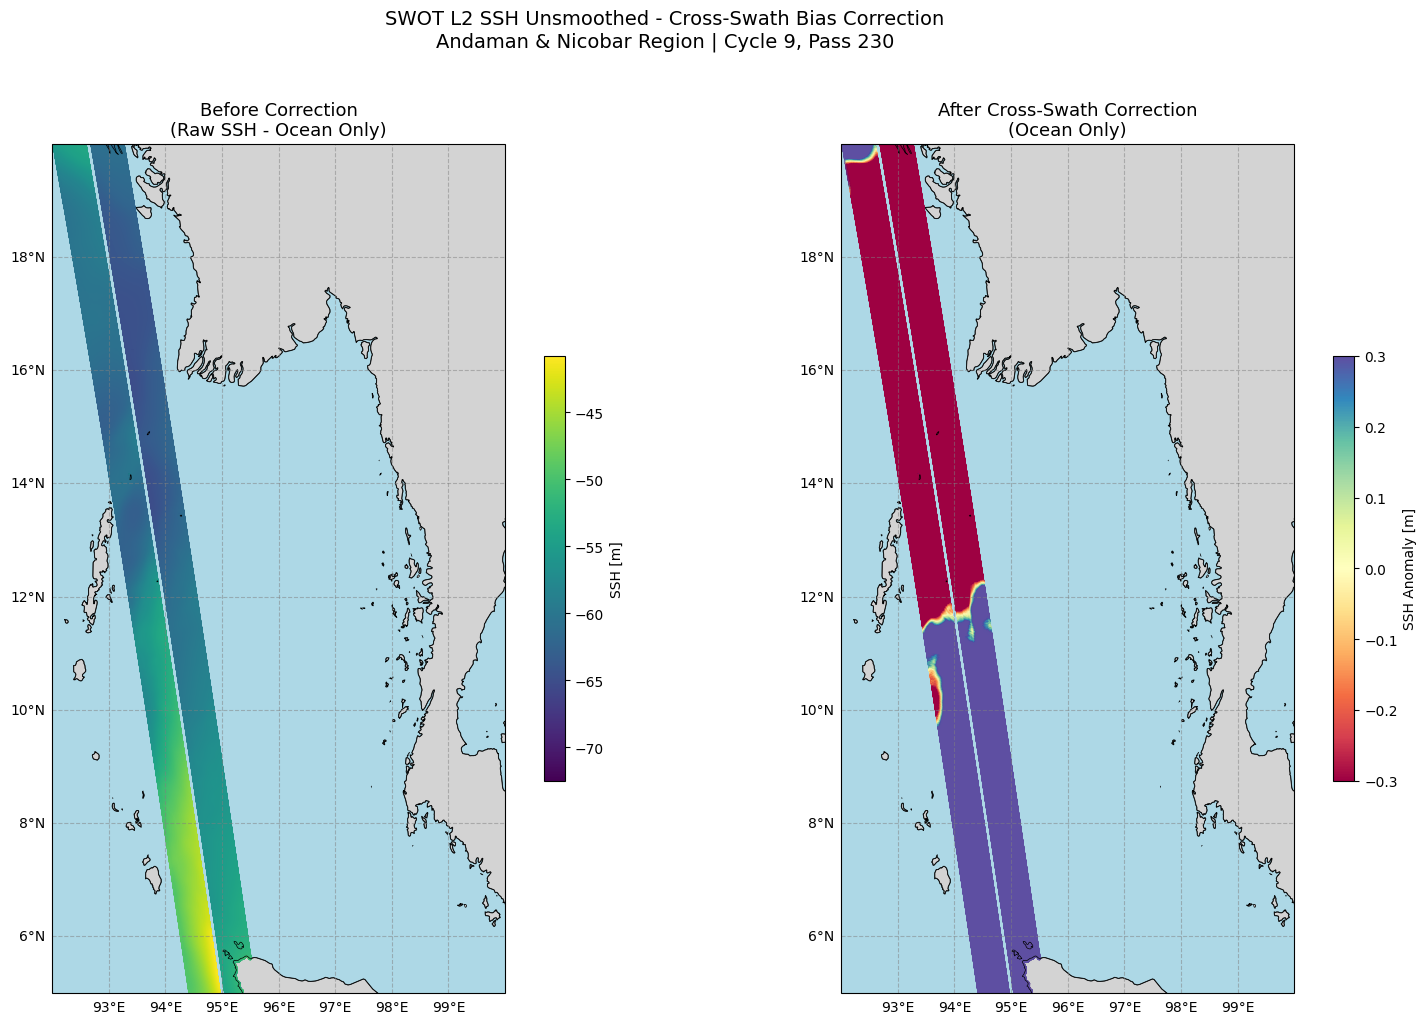

In [84]:
# Side-by-side comparison: Before and After Correction (Ocean Only - Andaman & Nicobar)
print("Creating side-by-side comparison (Ocean Only - Andaman & Nicobar Region)...")

fig, axes = plt.subplots(1, 2, figsize=(16, 10), 
                          subplot_kw=dict(projection=ccrs.PlateCarree()))

# Check if we have data
has_data = False
for swath_name in ['left', 'right']:
    if np.sum(~np.isnan(corrected_data[swath_name]['ssh_corrected'])) > 0:
        has_data = True
        break

if not has_data:
    plt.close()
    print("⚠️ No ocean data available in Andaman & Nicobar region for comparison!")
else:
    # Plot 1: Before correction (raw SSH - ocean only in region)
    ax1 = axes[0]
    ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
    ax1.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)

    for swath_name in ['left', 'right']:
        data = corrected_data[swath_name]
        lon, lat = data['lon'], data['lat']
        ssh = data['ssh_raw']
        ocean_mask = data['ocean_mask']
        region_mask = data['region_mask']
        
        # Apply masks to raw data
        valid_mask = ocean_mask & region_mask & ~np.isnan(ssh)
        
        if np.sum(valid_mask) > 0:
            cax1 = ax1.scatter(lon[valid_mask], lat[valid_mask], 
                               c=ssh[valid_mask], s=0.5, 
                               cmap='viridis', 
                               transform=ccrs.PlateCarree())

    cbar1 = plt.colorbar(cax1, ax=ax1, shrink=0.5)
    cbar1.set_label('SSH [m]')
    ax1.set_extent([ANDAMAN_LON_BOUNDS[0], ANDAMAN_LON_BOUNDS[1], 
                    ANDAMAN_LAT_BOUNDS[0], ANDAMAN_LAT_BOUNDS[1]], crs=ccrs.PlateCarree())
    ax1.set_title('Before Correction\n(Raw SSH - Ocean Only)', fontsize=13)
    gl1 = ax1.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    gl1.right_labels = False
    gl1.top_labels = False

    # Plot 2: After correction
    ax2 = axes[1]
    ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
    ax2.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)

    for swath_name in ['left', 'right']:
        data = corrected_data[swath_name]
        lon, lat = data['lon'], data['lat']
        ssh_corr = data['ssh_corrected']
        
        m = ~np.isnan(ssh_corr)
        if np.sum(m) > 0:
            cax2 = ax2.scatter(lon[m], lat[m], 
                               c=ssh_corr[m], s=0.5, 
                               vmin=-0.3, vmax=0.3,
                               cmap=plt.cm.Spectral, 
                               transform=ccrs.PlateCarree())

    cbar2 = plt.colorbar(cax2, ax=ax2, shrink=0.5)
    cbar2.set_label('SSH Anomaly [m]')
    ax2.set_extent([ANDAMAN_LON_BOUNDS[0], ANDAMAN_LON_BOUNDS[1], 
                    ANDAMAN_LAT_BOUNDS[0], ANDAMAN_LAT_BOUNDS[1]], crs=ccrs.PlateCarree())
    ax2.set_title('After Cross-Swath Correction\n(Ocean Only)', fontsize=13)
    gl2 = ax2.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    gl2.right_labels = False
    gl2.top_labels = False

    plt.suptitle(f'SWOT L2 SSH Unsmoothed - Cross-Swath Bias Correction\n'
                 f'Andaman & Nicobar Region | Cycle {ds_root.attrs.get("cycle_number")}, '
                 f'Pass {ds_root.attrs.get("pass_number")}', 
                 fontsize=14, y=1.02)

    plt.tight_layout()
    plt.show()

## Cell 18: Cross-Track Profile Analysis

Analyzing cross-track profiles...

LEFT SWATH:
  Cross-track bias before: 2095.6314 m
  Cross-track bias after: 3.0125 m
  Bias reduction: 99.9%

RIGHT SWATH:
  Cross-track bias before: 2093.3912 m
  Cross-track bias after: 0.0302 m
  Bias reduction: 100.0%


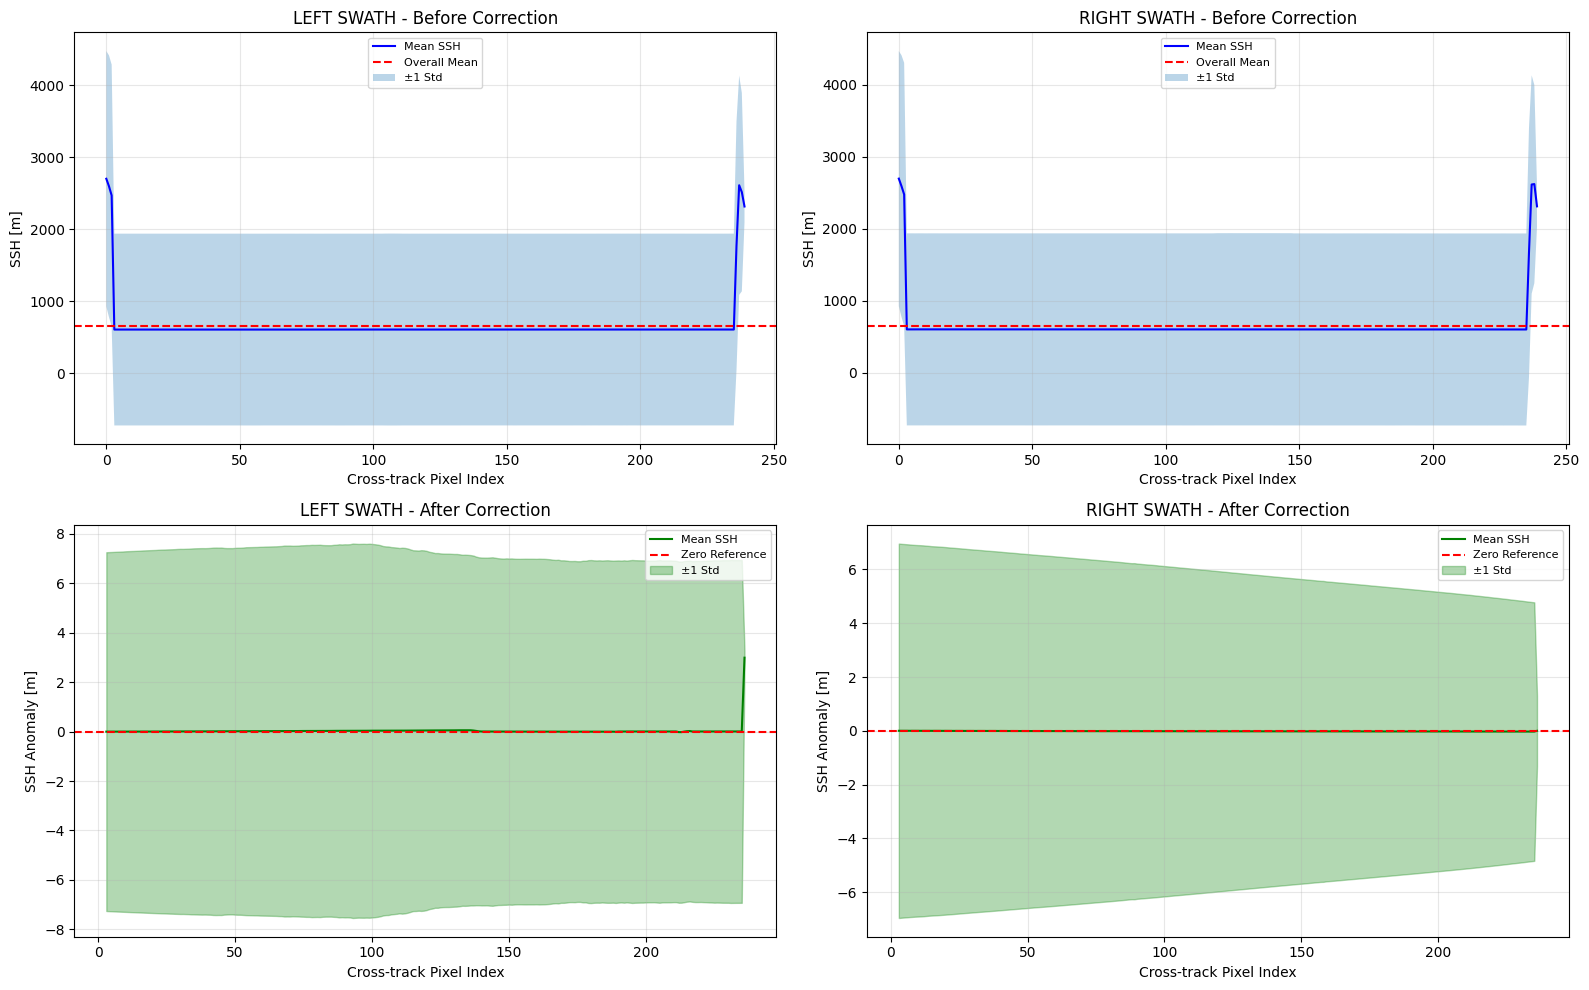

In [96]:
# Cross-track profile analysis to visualize the correction effect
print("Analyzing cross-track profiles...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, swath_name in enumerate(['left', 'right']):
    data = corrected_data[swath_name]
    ssh_raw = data['ssh_raw']
    ssh_corr = data['ssh_corrected']
    
    # Calculate mean cross-track profiles
    ssh_mean_before = np.nanmean(ssh_raw, axis=0)
    ssh_mean_after = np.nanmean(ssh_corr, axis=0)
    cross_track_distance = np.arange(len(ssh_mean_before))
    
    # Plot Before correction
    ax1 = axes[0, idx]
    ax1.plot(cross_track_distance, ssh_mean_before, 'b-', linewidth=1.5, label='Mean SSH')
    ax1.axhline(y=np.nanmean(ssh_mean_before), color='r', linestyle='--', label='Overall Mean')
    ax1.fill_between(cross_track_distance, 
                      ssh_mean_before - np.nanstd(ssh_raw, axis=0),
                      ssh_mean_before + np.nanstd(ssh_raw, axis=0),
                      alpha=0.3, label='±1 Std')
    ax1.set_xlabel('Cross-track Pixel Index')
    ax1.set_ylabel('SSH [m]')
    ax1.set_title(f'{swath_name.upper()} SWATH - Before Correction')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Plot After correction
    ax2 = axes[1, idx]
    ax2.plot(cross_track_distance, ssh_mean_after, 'g-', linewidth=1.5, label='Mean SSH')
    ax2.axhline(y=0, color='r', linestyle='--', label='Zero Reference')
    ax2.fill_between(cross_track_distance, 
                      ssh_mean_after - np.nanstd(ssh_corr, axis=0),
                      ssh_mean_after + np.nanstd(ssh_corr, axis=0),
                      alpha=0.3, color='green', label='±1 Std')
    ax2.set_xlabel('Cross-track Pixel Index')
    ax2.set_ylabel('SSH Anomaly [m]')
    ax2.set_title(f'{swath_name.upper()} SWATH - After Correction')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # Print bias reduction
    bias_before = np.nanmax(ssh_mean_before) - np.nanmin(ssh_mean_before)
    bias_after = np.nanmax(ssh_mean_after) - np.nanmin(ssh_mean_after)
    print(f"\n{swath_name.upper()} SWATH:")
    print(f"  Cross-track bias before: {bias_before:.4f} m")
    print(f"  Cross-track bias after: {bias_after:.4f} m")
    print(f"  Bias reduction: {(1 - bias_after/bias_before)*100:.1f}%")

plt.tight_layout()
plt.show()

## Cell 19: Summary Statistics

In [97]:
# Summary statistics
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

for swath_name in ['left', 'right']:
    data = corrected_data[swath_name]
    ssh_raw = data['ssh_raw']
    ssh_corr = data['ssh_corrected']
    lat = data['lat']
    lon = data['lon']
    
    print(f"\n{'='*40}")
    print(f"{swath_name.upper()} SWATH")
    print(f"{'='*40}")
    
    print("\n--- Original SSH Data ---")
    print(f"  Min: {np.nanmin(ssh_raw):.4f} m")
    print(f"  Max: {np.nanmax(ssh_raw):.4f} m")
    print(f"  Mean: {np.nanmean(ssh_raw):.4f} m")
    print(f"  Std: {np.nanstd(ssh_raw):.4f} m")
    
    print("\n--- Corrected SSH Data ---")
    print(f"  Min: {np.nanmin(ssh_corr):.4f} m")
    print(f"  Max: {np.nanmax(ssh_corr):.4f} m")
    print(f"  Mean: {np.nanmean(ssh_corr):.4f} m")
    print(f"  Std: {np.nanstd(ssh_corr):.4f} m")
    
    print("\n--- Data Coverage ---")
    print(f"  Total pixels: {ssh_raw.size}")
    print(f"  Valid pixels (original): {np.sum(~np.isnan(ssh_raw))}")
    print(f"  Valid pixels (corrected): {np.sum(~np.isnan(ssh_corr))}")
    print(f"  Coverage: {100 * np.sum(~np.isnan(ssh_corr)) / ssh_raw.size:.2f}%")
    
    print("\n--- Geographic Extent ---")
    print(f"  Latitude: {np.nanmin(lat):.4f}° to {np.nanmax(lat):.4f}°")
    print(f"  Longitude: {np.nanmin(lon):.4f}° to {np.nanmax(lon):.4f}°")

SUMMARY STATISTICS

LEFT SWATH

--- Original SSH Data ---
  Min: -260.4554 m
  Max: 5681.9475 m
  Mean: 610.5850 m
  Std: 1337.2105 m

--- Corrected SSH Data ---
  Min: -24.8122 m
  Max: 37.4247 m
  Mean: 0.0142 m
  Std: 7.2135 m

--- Data Coverage ---
  Total pixels: 19924080
  Valid pixels (original): 19402050
  Valid pixels (corrected): 1618819
  Coverage: 8.12%

--- Geographic Extent ---
  Latitude: -77.6188° to 78.2480°
  Longitude: 12.2076° to 179.2468°

RIGHT SWATH

--- Original SSH Data ---
  Min: -102.7414 m
  Max: 5684.4159 m
  Mean: 609.8541 m
  Std: 1337.3472 m

--- Corrected SSH Data ---
  Min: -16.5207 m
  Max: 12.7480 m
  Mean: -0.0160 m
  Std: 5.9726 m

--- Data Coverage ---
  Total pixels: 19924080
  Valid pixels (original): 19399138
  Valid pixels (corrected): 1659457
  Coverage: 8.33%

--- Geographic Extent ---
  Latitude: -78.2458° to 77.6213°
  Longitude: 12.2097° to 179.2485°


## Cell 20: Close Dataset

In [98]:
# Close the datasets
ds_root.close()
ds_left.close()
ds_right.close()
print("All datasets closed successfully!")
print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print("""
Summary of what was done:
1. Loaded SWOT L2 LR SSH Unsmoothed data from left and right swaths
2. Explored file structure, global attributes, dimensions, and variables
3. Displayed geographic coverage and time information
4. Plotted raw SSH data on a map (both swaths)
5. Applied cross-swath bias correction (ad hoc method)
6. Plotted corrected SSH data with before/after comparison
7. Analyzed cross-track profiles to visualize correction effect

Note: The cross-swath correction is an ad hoc approach that removes 
along-track mean for each cross-track position. This may introduce 
errors in coastal/inland waters with limited data segments.
""")

All datasets closed successfully!

ANALYSIS COMPLETE!

Summary of what was done:
1. Loaded SWOT L2 LR SSH Unsmoothed data from left and right swaths
2. Explored file structure, global attributes, dimensions, and variables
3. Displayed geographic coverage and time information
4. Plotted raw SSH data on a map (both swaths)
5. Applied cross-swath bias correction (ad hoc method)
6. Plotted corrected SSH data with before/after comparison
7. Analyzed cross-track profiles to visualize correction effect

Note: The cross-swath correction is an ad hoc approach that removes 
along-track mean for each cross-track position. This may introduce 
errors in coastal/inland waters with limited data segments.



---
# Part 4: Internal Wave Analysis

Internal waves are gravity waves that propagate within the ocean interior along density interfaces. 
In the Andaman Sea, they are generated primarily by tidal forcing over the Andaman-Nicobar Ridge.

**Typical Internal Wave Characteristics in Andaman Sea:**
- Wavelengths: 5-30 km (up to 100+ km for large-amplitude waves)
- Amplitudes: 0.01-0.2 m in SSH (surface expression)
- Propagation: Primarily eastward from the ridge

**Analysis Methods:**
1. High-pass filtering to isolate internal wave signals
2. Spectral analysis to identify dominant wavelengths
3. Along-track/across-track profile analysis

In [101]:
# Re-open the datasets for internal wave analysis
nc_file = r"C:\Users\abhik\Desktop\project related work\SWOT_L2_LR_SSH_Unsmoothed_009_230_20240112T075548_20240112T084715_PGC0_02.nc"

ds_root = xr.open_dataset(nc_file)
ds_left = xr.open_dataset(nc_file, group='left', engine='netcdf4')
ds_right = xr.open_dataset(nc_file, group='right', engine='netcdf4')

# Import additional libraries for internal wave analysis
from scipy import signal
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
from scipy.fft import fft, fftfreq

print("Datasets re-opened for internal wave analysis!")
print(f"File: {nc_file.split(chr(92))[-1]}")

Datasets re-opened for internal wave analysis!
File: SWOT_L2_LR_SSH_Unsmoothed_009_230_20240112T075548_20240112T084715_PGC0_02.nc


## Cell 21: Define Internal Wave Analysis Functions

In [102]:
# Internal Wave Analysis Functions

def apply_high_pass_filter(data_2d, sigma=20, axis=0):
    """
    Apply high-pass filter to isolate internal wave signals.
    
    Parameters:
    -----------
    data_2d : numpy.ndarray
        2D SSH data (num_lines x num_pixels)
    sigma : float
        Gaussian filter sigma (larger = removes larger scale features)
        For 250m resolution: sigma=20 removes ~5km features
                            sigma=40 removes ~10km features
                            sigma=80 removes ~20km features
    axis : int
        0 = along-track, 1 = across-track
        
    Returns:
    --------
    high_pass_data : numpy.ndarray
        High-pass filtered data showing internal wave signals
    """
    # Make a copy and handle NaNs
    data = data_2d.copy()
    
    # Store NaN locations
    nan_mask = np.isnan(data)
    
    # Replace NaNs with interpolated values for filtering
    # Use along-track mean for each column
    for j in range(data.shape[1]):
        col = data[:, j]
        valid = ~np.isnan(col)
        if np.sum(valid) > 0:
            col_mean = np.nanmean(col)
            data[np.isnan(col), j] = col_mean
    
    # Apply Gaussian low-pass filter
    low_pass = gaussian_filter1d(data, sigma=sigma, axis=axis, mode='nearest')
    
    # High-pass = original - low-pass
    high_pass = data_2d - low_pass
    
    # Restore NaN mask
    high_pass[nan_mask] = np.nan
    
    return high_pass

def compute_power_spectrum(signal_1d, dx=0.25):
    """
    Compute power spectral density of a 1D signal.
    
    Parameters:
    -----------
    signal_1d : numpy.ndarray
        1D signal (e.g., along-track SSH profile)
    dx : float
        Spatial resolution in km (default 0.25 km for 250m SWOT)
        
    Returns:
    --------
    wavelengths : numpy.ndarray
        Wavelengths in km
    psd : numpy.ndarray
        Power spectral density
    """
    # Remove NaNs
    valid = ~np.isnan(signal_1d)
    if np.sum(valid) < 50:
        return None, None
    
    clean_signal = signal_1d[valid]
    n = len(clean_signal)
    
    # Remove mean
    clean_signal = clean_signal - np.mean(clean_signal)
    
    # Apply window to reduce spectral leakage
    window = signal.windows.hann(n)
    windowed = clean_signal * window
    
    # Compute FFT
    fft_vals = fft(windowed)
    psd = np.abs(fft_vals[:n//2])**2 / n
    
    # Compute frequencies and wavelengths
    freqs = fftfreq(n, dx)[:n//2]
    wavelengths = np.where(freqs > 0, 1/freqs, np.inf)
    
    return wavelengths[1:], psd[1:]  # Skip zero frequency

def estimate_wave_properties(filtered_data, lat, lon, dx=0.25):
    """
    Estimate internal wave properties from filtered SSH data.
    
    Parameters:
    -----------
    filtered_data : numpy.ndarray
        High-pass filtered SSH data
    lat, lon : numpy.ndarray
        Latitude and longitude arrays
    dx : float
        Along-track resolution in km
        
    Returns:
    --------
    wave_stats : dict
        Dictionary containing wave amplitude, wavelength estimates
    """
    valid_data = filtered_data[~np.isnan(filtered_data)]
    
    if len(valid_data) == 0:
        return None
    
    # RMS amplitude (typical internal wave amplitude measure)
    rms_amplitude = np.sqrt(np.mean(valid_data**2))
    
    # Peak-to-peak amplitude
    peak_amplitude = np.nanmax(filtered_data) - np.nanmin(filtered_data)
    
    # Standard deviation
    std_amplitude = np.std(valid_data)
    
    # Estimate dominant wavelength from center track
    center_col = filtered_data.shape[1] // 2
    center_track = filtered_data[:, center_col]
    
    wavelengths, psd = compute_power_spectrum(center_track, dx)
    
    if wavelengths is not None and len(wavelengths) > 0:
        # Find wavelength with maximum power (in internal wave band 1-100 km)
        iw_mask = (wavelengths > 1) & (wavelengths < 100)
        if np.sum(iw_mask) > 0:
            iw_wavelengths = wavelengths[iw_mask]
            iw_psd = psd[iw_mask]
            dominant_wavelength = iw_wavelengths[np.argmax(iw_psd)]
        else:
            dominant_wavelength = np.nan
    else:
        dominant_wavelength = np.nan
    
    return {
        'rms_amplitude_m': rms_amplitude,
        'peak_amplitude_m': peak_amplitude,
        'std_amplitude_m': std_amplitude,
        'dominant_wavelength_km': dominant_wavelength,
        'lat_range': (np.nanmin(lat), np.nanmax(lat)),
        'lon_range': (np.nanmin(lon), np.nanmax(lon))
    }

print("Internal wave analysis functions defined!")
print("  - apply_high_pass_filter(): Isolate internal wave signals")
print("  - compute_power_spectrum(): Spectral analysis")
print("  - estimate_wave_properties(): Wave amplitude/wavelength estimation")

Internal wave analysis functions defined!
  - apply_high_pass_filter(): Isolate internal wave signals
  - compute_power_spectrum(): Spectral analysis
  - estimate_wave_properties(): Wave amplitude/wavelength estimation


## Cell 22: Apply Internal Wave Filtering to Andaman Sea Data

In [103]:
# Apply Internal Wave Filtering to Andaman Sea Region
print("Applying internal wave filtering to Andaman Sea region...")

# Andaman Sea region bounds
ANDAMAN_LAT_BOUNDS = (5.0, 20.0)   # Latitude: 5°N to 20°N
ANDAMAN_LON_BOUNDS = (92.0, 100.0)  # Longitude: 92°E to 100°E

# Filter parameters for different internal wave scales
# SWOT Unsmoothed has ~250m along-track resolution
ALONG_TRACK_RES = 0.25  # km

# High-pass filter sigma values to test
# sigma=40 -> removes features >10km (keeps 1-10 km waves)
# sigma=80 -> removes features >20km (keeps 1-20 km waves)
# sigma=160 -> removes features >40km (keeps 1-40 km waves)
FILTER_SIGMA = 80  # Tune this for your internal wave scales

# Store filtered data for both swaths
internal_wave_data = {}

for swath_name, ds_swath in [('left', ds_left), ('right', ds_right)]:
    print(f"\n{swath_name.upper()} SWATH:")
    
    lat = ds_swath.coords['latitude'].values
    lon = ds_swath.coords['longitude'].values
    ssh = ds_swath['ssh_karin_2'].values
    
    # Get ocean mask
    if 'ancillary_surface_classification_flag' in ds_swath:
        surf_flag = ds_swath['ancillary_surface_classification_flag'].values
        ocean_mask = (surf_flag == 0)
    else:
        ocean_mask = ~np.isnan(ssh)
    
    # Regional mask for Andaman Sea
    region_mask = (lat >= ANDAMAN_LAT_BOUNDS[0]) & (lat <= ANDAMAN_LAT_BOUNDS[1]) & \
                  (lon >= ANDAMAN_LON_BOUNDS[0]) & (lon <= ANDAMAN_LON_BOUNDS[1])
    
    # Combined mask
    valid_mask = ocean_mask & region_mask & ~np.isnan(ssh)
    
    # Check if we have data
    valid_count = np.sum(valid_mask)
    print(f"  Valid ocean pixels in Andaman Sea: {valid_count}")
    
    if valid_count > 1000:
        # Apply ocean mask to SSH
        ssh_masked = np.where(ocean_mask, ssh, np.nan)
        
        # Apply high-pass filter along track
        ssh_filtered = apply_high_pass_filter(ssh_masked, sigma=FILTER_SIGMA, axis=0)
        
        # Apply regional mask to filtered data
        ssh_filtered_region = np.where(valid_mask, ssh_filtered, np.nan)
        
        # Estimate wave properties
        wave_stats = estimate_wave_properties(ssh_filtered_region, lat, lon, ALONG_TRACK_RES)
        
        internal_wave_data[swath_name] = {
            'ssh_raw': ssh,
            'ssh_filtered': ssh_filtered_region,
            'lat': lat,
            'lon': lon,
            'ocean_mask': ocean_mask,
            'region_mask': region_mask,
            'valid_mask': valid_mask,
            'wave_stats': wave_stats
        }
        
        if wave_stats:
            print(f"  Internal Wave Properties:")
            print(f"    RMS Amplitude: {wave_stats['rms_amplitude_m']*100:.2f} cm")
            print(f"    Peak-to-Peak: {wave_stats['peak_amplitude_m']*100:.2f} cm")
            print(f"    Dominant Wavelength: {wave_stats['dominant_wavelength_km']:.1f} km")
    else:
        print(f"  ⚠️ Insufficient data in Andaman Sea region")
        internal_wave_data[swath_name] = None

print("\n✓ Internal wave filtering complete!")

Applying internal wave filtering to Andaman Sea region...

LEFT SWATH:
  Valid ocean pixels in Andaman Sea: 1618819
  Internal Wave Properties:
    RMS Amplitude: 57.03 cm
    Peak-to-Peak: 5235.03 cm
    Dominant Wavelength: 64.0 km

RIGHT SWATH:
  Valid ocean pixels in Andaman Sea: 1659457
  Internal Wave Properties:
    RMS Amplitude: 14.71 cm
    Peak-to-Peak: 2851.35 cm
    Dominant Wavelength: 98.9 km

✓ Internal wave filtering complete!


## Cell 23: Visualize Internal Wave Signals

Creating internal wave visualization...


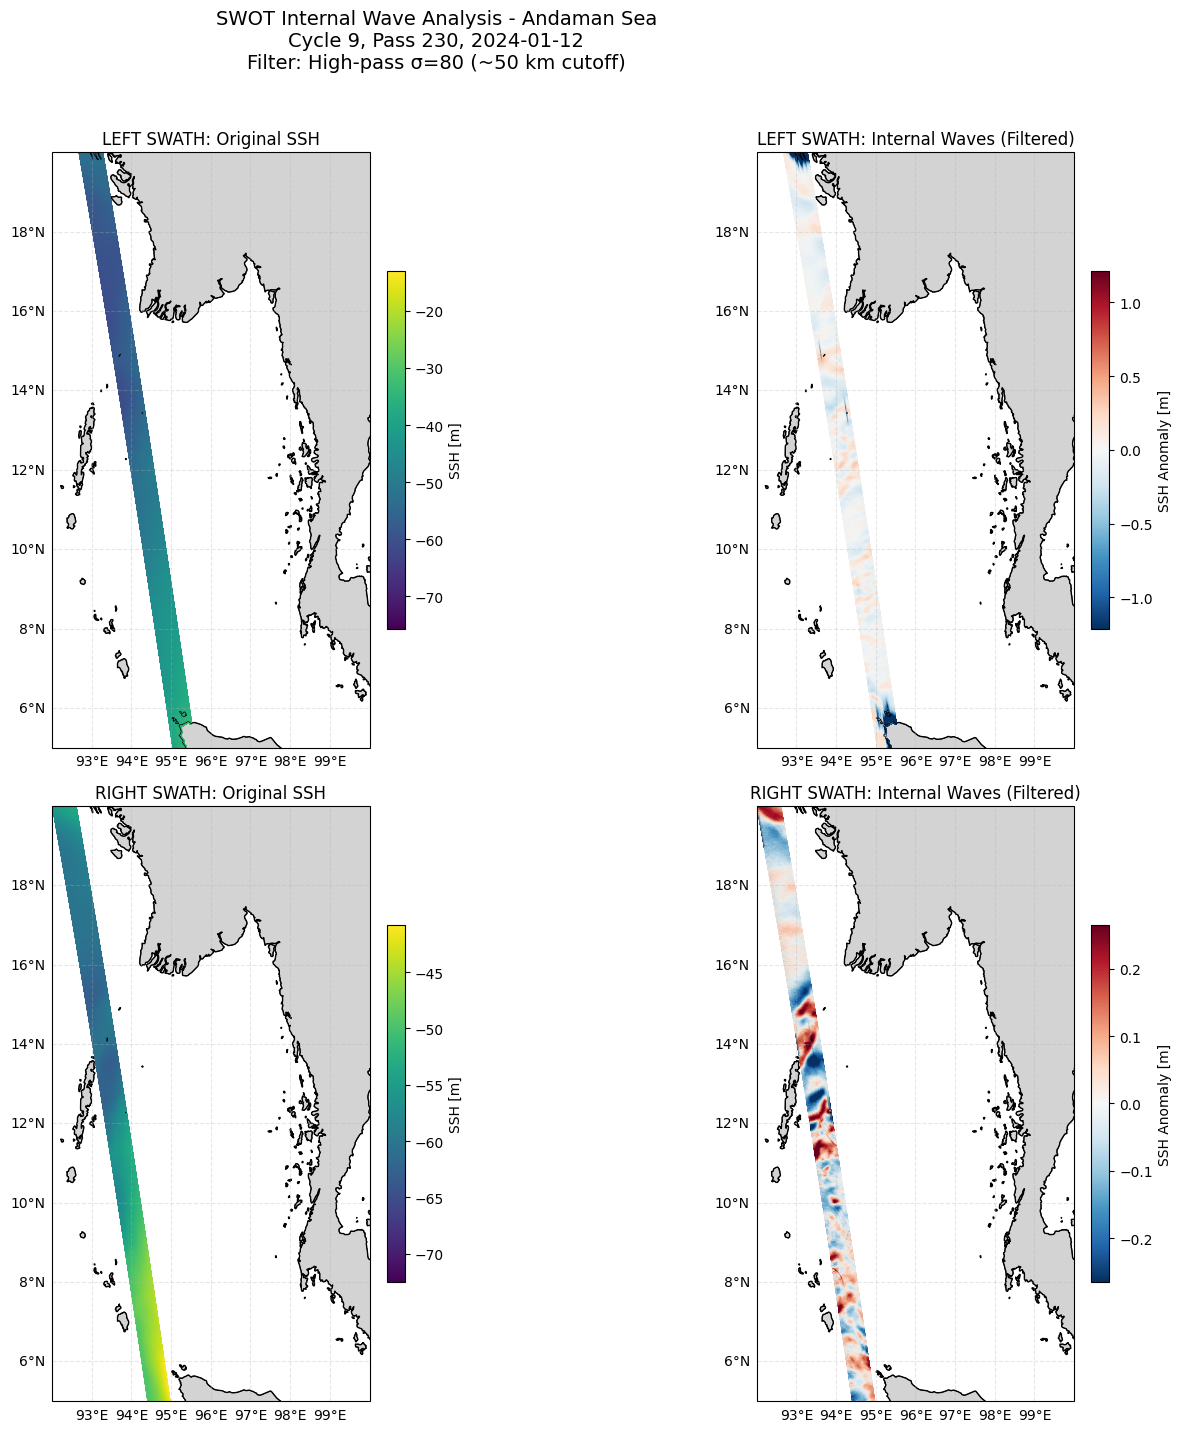

In [104]:
# Visualize Internal Wave Signals - Comparison Plot
print("Creating internal wave visualization...")

# Check if we have data
has_data = any(internal_wave_data.get(s) is not None for s in ['left', 'right'])

if not has_data:
    print("⚠️ No internal wave data available in Andaman Sea region!")
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 14), 
                              subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Plot settings
    titles = [
        'Original SSH (Ocean Only)',
        'Internal Waves (High-Pass Filtered)',
        'Original SSH (Ocean Only)',
        'Internal Waves (High-Pass Filtered)'
    ]
    
    row_labels = ['LEFT SWATH', 'RIGHT SWATH']
    
    for idx, swath_name in enumerate(['left', 'right']):
        data = internal_wave_data.get(swath_name)
        
        if data is None:
            for col in range(2):
                axes[idx, col].text(0.5, 0.5, f'No data for {swath_name} swath', 
                                   ha='center', va='center', transform=axes[idx, col].transAxes)
            continue
        
        lat = data['lat']
        lon = data['lon']
        ssh_raw = data['ssh_raw']
        ssh_filtered = data['ssh_filtered']
        valid_mask = data['valid_mask']
        
        # Left column: Original SSH
        ax1 = axes[idx, 0]
        ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
        ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
        
        raw_masked = np.where(valid_mask, ssh_raw, np.nan)
        m = ~np.isnan(raw_masked)
        if np.sum(m) > 0:
            cax1 = ax1.scatter(lon[m], lat[m], c=raw_masked[m], s=0.3,
                              cmap='viridis', transform=ccrs.PlateCarree())
            cbar1 = plt.colorbar(cax1, ax=ax1, shrink=0.6, pad=0.02)
            cbar1.set_label('SSH [m]')
        
        ax1.set_extent([ANDAMAN_LON_BOUNDS[0], ANDAMAN_LON_BOUNDS[1], 
                       ANDAMAN_LAT_BOUNDS[0], ANDAMAN_LAT_BOUNDS[1]], crs=ccrs.PlateCarree())
        ax1.set_title(f'{row_labels[idx]}: Original SSH', fontsize=12)
        gl1 = ax1.gridlines(draw_labels=True, alpha=0.3, linestyle='--')
        gl1.right_labels = False
        gl1.top_labels = False
        
        # Right column: Filtered (Internal Waves)
        ax2 = axes[idx, 1]
        ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
        ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
        
        m = ~np.isnan(ssh_filtered)
        if np.sum(m) > 0:
            # Use symmetric colorbar for internal waves
            vmax = np.nanpercentile(np.abs(ssh_filtered[m]), 98)
            cax2 = ax2.scatter(lon[m], lat[m], c=ssh_filtered[m], s=0.3,
                              cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                              transform=ccrs.PlateCarree())
            cbar2 = plt.colorbar(cax2, ax=ax2, shrink=0.6, pad=0.02)
            cbar2.set_label('SSH Anomaly [m]')
        
        ax2.set_extent([ANDAMAN_LON_BOUNDS[0], ANDAMAN_LON_BOUNDS[1], 
                       ANDAMAN_LAT_BOUNDS[0], ANDAMAN_LAT_BOUNDS[1]], crs=ccrs.PlateCarree())
        ax2.set_title(f'{row_labels[idx]}: Internal Waves (Filtered)', fontsize=12)
        gl2 = ax2.gridlines(draw_labels=True, alpha=0.3, linestyle='--')
        gl2.right_labels = False
        gl2.top_labels = False
    
    plt.suptitle(f'SWOT Internal Wave Analysis - Andaman Sea\n'
                 f'Cycle {ds_root.attrs.get("cycle_number")}, Pass {ds_root.attrs.get("pass_number")}, '
                 f'{ds_root.attrs.get("time_coverage_start", "")[:10]}\n'
                 f'Filter: High-pass σ={FILTER_SIGMA} (~{FILTER_SIGMA*ALONG_TRACK_RES*2.5:.0f} km cutoff)',
                 fontsize=14, y=1.02)
    
    plt.tight_layout()
    plt.show()

## Cell 24: Along-Track Internal Wave Profile Analysis

Analyzing along-track internal wave profiles...


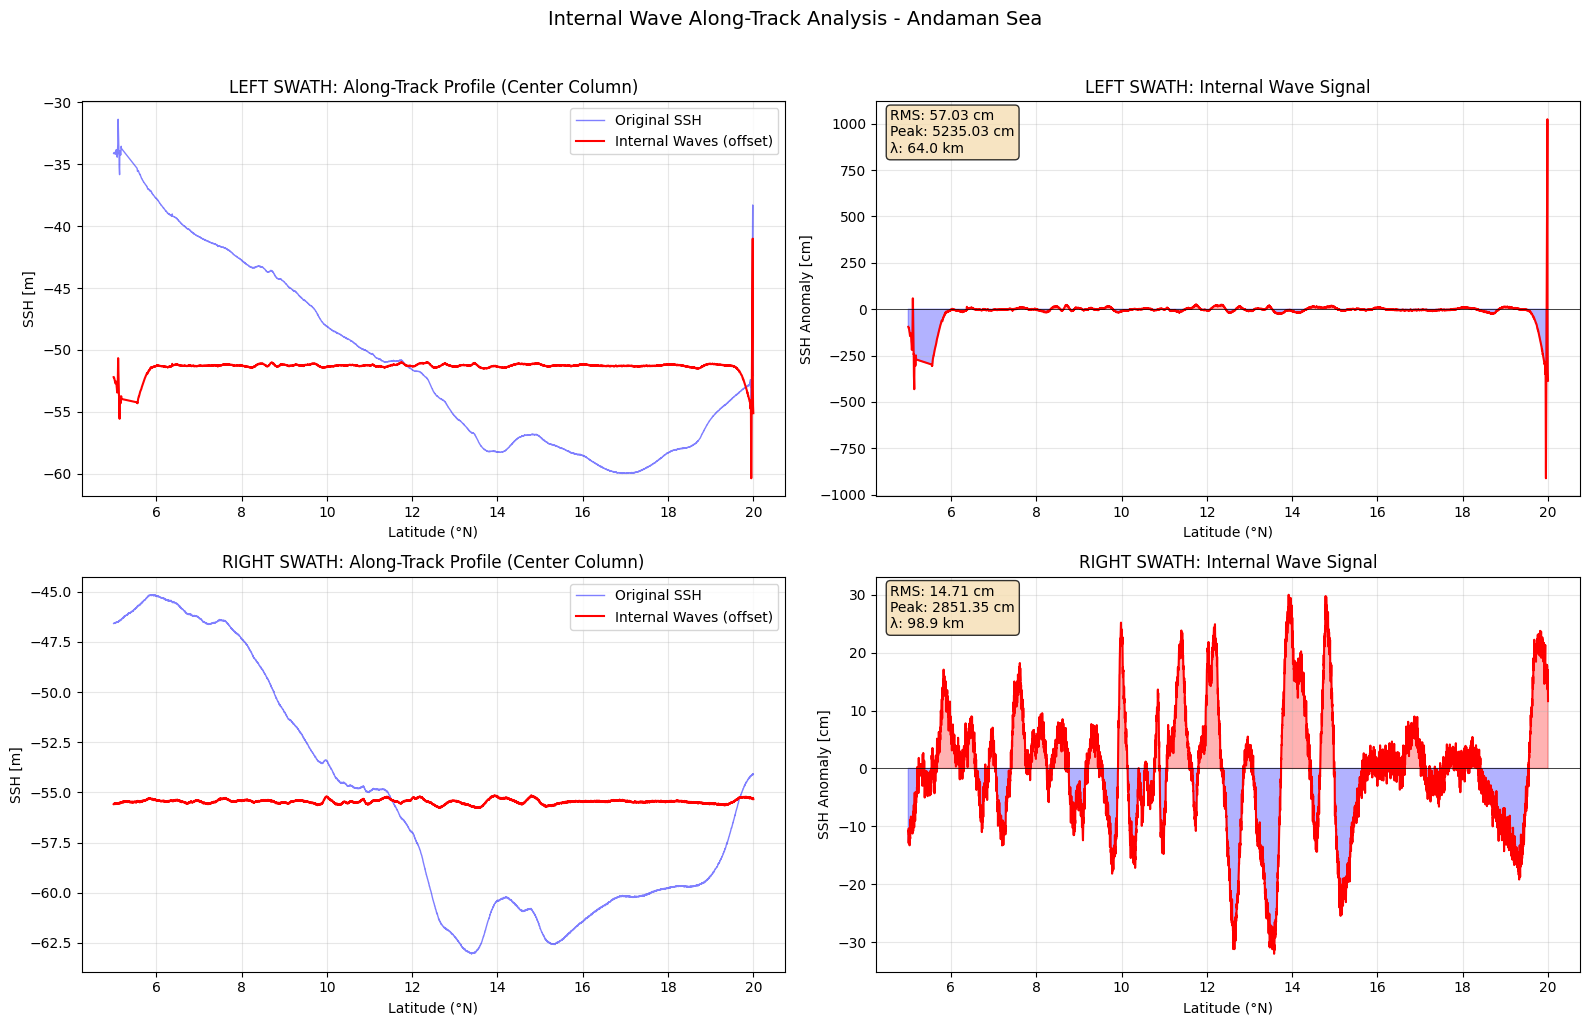

In [105]:
# Along-Track Internal Wave Profile Analysis
print("Analyzing along-track internal wave profiles...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, swath_name in enumerate(['left', 'right']):
    data = internal_wave_data.get(swath_name)
    
    if data is None:
        axes[idx, 0].text(0.5, 0.5, f'No data for {swath_name} swath', 
                         ha='center', va='center')
        axes[idx, 1].text(0.5, 0.5, f'No data for {swath_name} swath', 
                         ha='center', va='center')
        continue
    
    lat = data['lat']
    ssh_raw = data['ssh_raw']
    ssh_filtered = data['ssh_filtered']
    valid_mask = data['valid_mask']
    
    # Select center column (nadir track)
    center_col = ssh_filtered.shape[1] // 2
    
    # Extract along-track profiles
    raw_profile = ssh_raw[:, center_col]
    filtered_profile = ssh_filtered[:, center_col]
    lat_profile = lat[:, center_col]
    
    # Find valid range in region
    valid_range = ~np.isnan(filtered_profile)
    
    if np.sum(valid_range) > 100:
        # Left plot: Raw vs Filtered SSH
        ax1 = axes[idx, 0]
        
        # Plot raw SSH (subset to valid range)
        raw_valid = ~np.isnan(raw_profile) & valid_range
        if np.sum(raw_valid) > 0:
            ax1.plot(lat_profile[raw_valid], raw_profile[raw_valid], 
                    'b-', alpha=0.5, linewidth=1, label='Original SSH')
        
        # Plot filtered internal waves
        filt_valid = ~np.isnan(filtered_profile)
        if np.sum(filt_valid) > 0:
            # Add offset for visibility
            offset = np.nanmean(raw_profile[raw_valid]) if np.sum(raw_valid) > 0 else 0
            ax1.plot(lat_profile[filt_valid], filtered_profile[filt_valid] + offset, 
                    'r-', linewidth=1.5, label='Internal Waves (offset)')
        
        ax1.set_xlabel('Latitude (°N)')
        ax1.set_ylabel('SSH [m]')
        ax1.set_title(f'{swath_name.upper()} SWATH: Along-Track Profile (Center Column)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Right plot: Internal wave signal only
        ax2 = axes[idx, 1]
        
        if np.sum(filt_valid) > 0:
            ax2.plot(lat_profile[filt_valid], filtered_profile[filt_valid] * 100, 
                    'r-', linewidth=1.5)
            ax2.fill_between(lat_profile[filt_valid], 0, filtered_profile[filt_valid] * 100,
                            where=filtered_profile[filt_valid] > 0, color='red', alpha=0.3)
            ax2.fill_between(lat_profile[filt_valid], 0, filtered_profile[filt_valid] * 100,
                            where=filtered_profile[filt_valid] < 0, color='blue', alpha=0.3)
        
        ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        ax2.set_xlabel('Latitude (°N)')
        ax2.set_ylabel('SSH Anomaly [cm]')
        ax2.set_title(f'{swath_name.upper()} SWATH: Internal Wave Signal')
        ax2.grid(True, alpha=0.3)
        
        # Add wave statistics annotation
        wave_stats = data.get('wave_stats')
        if wave_stats:
            stats_text = f"RMS: {wave_stats['rms_amplitude_m']*100:.2f} cm\n"
            stats_text += f"Peak: {wave_stats['peak_amplitude_m']*100:.2f} cm\n"
            stats_text += f"λ: {wave_stats['dominant_wavelength_km']:.1f} km"
            ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    else:
        axes[idx, 0].text(0.5, 0.5, f'Insufficient data in region', ha='center', va='center')
        axes[idx, 1].text(0.5, 0.5, f'Insufficient data in region', ha='center', va='center')

plt.suptitle('Internal Wave Along-Track Analysis - Andaman Sea', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Cell 25: Spectral Analysis of Internal Waves

Computing power spectral density for internal wave analysis...


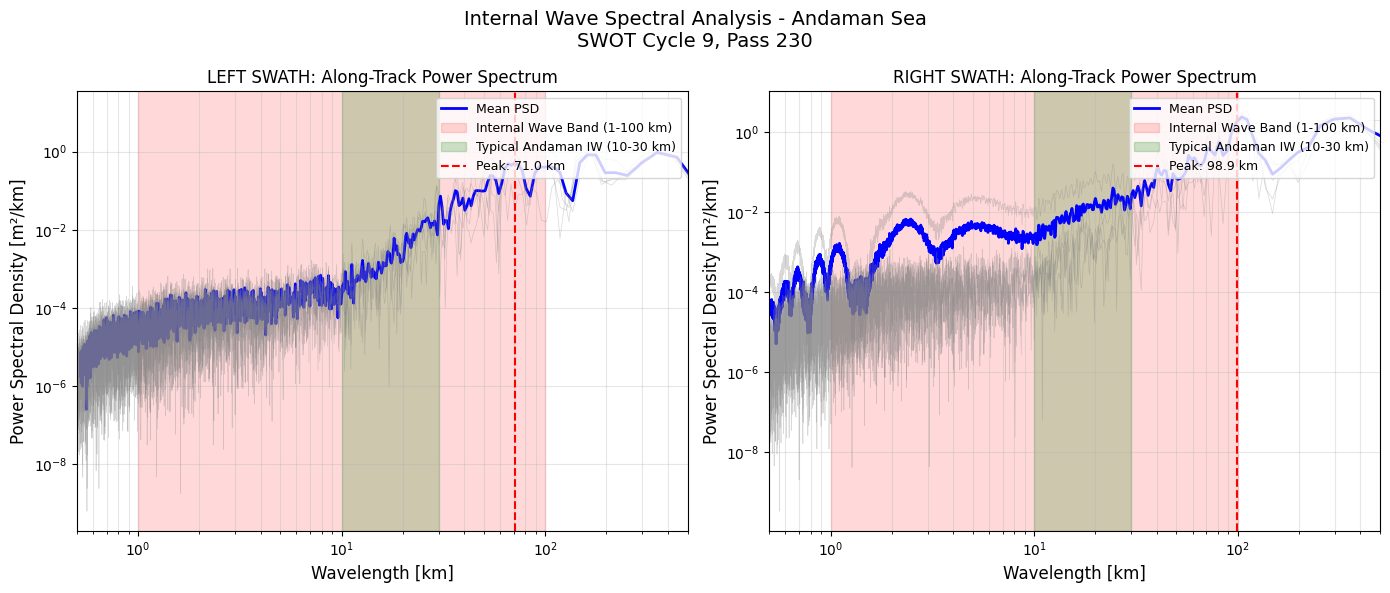


Spectral analysis complete!
Peak wavelengths indicate dominant internal wave scales.


In [106]:
# Spectral Analysis of Internal Waves
print("Computing power spectral density for internal wave analysis...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, swath_name in enumerate(['left', 'right']):
    data = internal_wave_data.get(swath_name)
    ax = axes[idx]
    
    if data is None:
        ax.text(0.5, 0.5, f'No data for {swath_name} swath', 
               ha='center', va='center', transform=ax.transAxes)
        continue
    
    ssh_filtered = data['ssh_filtered']
    valid_mask = data['valid_mask']
    
    # Compute spectra from multiple across-track columns
    all_wavelengths = []
    all_psd = []
    
    # Sample multiple columns
    n_cols = ssh_filtered.shape[1]
    sample_cols = np.linspace(n_cols//4, 3*n_cols//4, 5, dtype=int)
    
    for col in sample_cols:
        profile = ssh_filtered[:, col]
        wavelengths, psd = compute_power_spectrum(profile, dx=ALONG_TRACK_RES)
        
        if wavelengths is not None and len(wavelengths) > 0:
            all_wavelengths.append(wavelengths)
            all_psd.append(psd)
    
    if all_psd:
        # Average spectra
        min_len = min(len(w) for w in all_wavelengths)
        avg_wavelengths = all_wavelengths[0][:min_len]
        avg_psd = np.mean([p[:min_len] for p in all_psd], axis=0)
        
        # Plot power spectrum
        ax.loglog(avg_wavelengths, avg_psd, 'b-', linewidth=2, label='Mean PSD')
        
        # Plot individual spectra (light)
        for i, (w, p) in enumerate(zip(all_wavelengths, all_psd)):
            ax.loglog(w, p, 'gray', alpha=0.3, linewidth=0.5)
        
        # Mark internal wave band (1-100 km typical)
        ax.axvspan(1, 100, alpha=0.15, color='red', label='Internal Wave Band (1-100 km)')
        
        # Mark typical Andaman Sea internal wave wavelengths (10-30 km)
        ax.axvspan(10, 30, alpha=0.2, color='green', label='Typical Andaman IW (10-30 km)')
        
        # Find peak in internal wave band
        iw_mask = (avg_wavelengths > 1) & (avg_wavelengths < 100)
        if np.sum(iw_mask) > 0:
            iw_wavelengths = avg_wavelengths[iw_mask]
            iw_psd = avg_psd[iw_mask]
            peak_idx = np.argmax(iw_psd)
            peak_wavelength = iw_wavelengths[peak_idx]
            ax.axvline(x=peak_wavelength, color='r', linestyle='--', linewidth=1.5,
                      label=f'Peak: {peak_wavelength:.1f} km')
        
        ax.set_xlabel('Wavelength [km]', fontsize=12)
        ax.set_ylabel('Power Spectral Density [m²/km]', fontsize=12)
        ax.set_title(f'{swath_name.upper()} SWATH: Along-Track Power Spectrum', fontsize=12)
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3, which='both')
        ax.set_xlim([0.5, 500])
    else:
        ax.text(0.5, 0.5, 'Insufficient data for spectral analysis', 
               ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Internal Wave Spectral Analysis - Andaman Sea\n'
             f'SWOT Cycle {ds_root.attrs.get("cycle_number")}, Pass {ds_root.attrs.get("pass_number")}',
             fontsize=14)
plt.tight_layout()
plt.show()

print("\nSpectral analysis complete!")
print("Peak wavelengths indicate dominant internal wave scales.")

## Cell 26: Internal Wave Summary Statistics

In [107]:
# Internal Wave Summary Statistics
print("=" * 80)
print("INTERNAL WAVE ANALYSIS SUMMARY - ANDAMAN SEA")
print("=" * 80)

print(f"\nFile: {nc_file.split(chr(92))[-1]}")
print(f"Cycle: {ds_root.attrs.get('cycle_number')}, Pass: {ds_root.attrs.get('pass_number')}")
print(f"Date: {ds_root.attrs.get('time_coverage_start', '')[:10]}")

print(f"\nRegion: Andaman Sea")
print(f"  Latitude: {ANDAMAN_LAT_BOUNDS[0]}°N to {ANDAMAN_LAT_BOUNDS[1]}°N")
print(f"  Longitude: {ANDAMAN_LON_BOUNDS[0]}°E to {ANDAMAN_LON_BOUNDS[1]}°E")

print(f"\nFilter Parameters:")
print(f"  High-pass σ = {FILTER_SIGMA}")
print(f"  Cutoff wavelength ≈ {FILTER_SIGMA * ALONG_TRACK_RES * 2.5:.0f} km")
print(f"  Along-track resolution: {ALONG_TRACK_RES} km (250 m)")

for swath_name in ['left', 'right']:
    data = internal_wave_data.get(swath_name)
    
    print(f"\n{'='*40}")
    print(f"{swath_name.upper()} SWATH")
    print(f"{'='*40}")
    
    if data is None:
        print("  ⚠️ No data available in Andaman Sea region")
        continue
    
    wave_stats = data.get('wave_stats')
    valid_mask = data['valid_mask']
    ssh_filtered = data['ssh_filtered']
    
    print(f"\nData Coverage:")
    print(f"  Valid ocean pixels: {np.sum(valid_mask)}")
    print(f"  Valid filtered pixels: {np.sum(~np.isnan(ssh_filtered))}")
    
    if wave_stats:
        print(f"\nInternal Wave Properties:")
        print(f"  RMS Amplitude:       {wave_stats['rms_amplitude_m']*100:.2f} cm")
        print(f"  Peak-to-Peak:        {wave_stats['peak_amplitude_m']*100:.2f} cm")
        print(f"  Std Deviation:       {wave_stats['std_amplitude_m']*100:.2f} cm")
        print(f"  Dominant Wavelength: {wave_stats['dominant_wavelength_km']:.1f} km")
        
        print(f"\nGeographic Extent (with data):")
        print(f"  Latitude:  {wave_stats['lat_range'][0]:.2f}°N to {wave_stats['lat_range'][1]:.2f}°N")
        print(f"  Longitude: {wave_stats['lon_range'][0]:.2f}°E to {wave_stats['lon_range'][1]:.2f}°E")

print("\n" + "=" * 80)
print("INTERPRETATION NOTES")
print("=" * 80)
print("""
• RMS Amplitude: Typical internal wave surface expression in Andaman Sea: 1-10 cm
• Wavelengths: 
  - Small-scale internal waves: 1-10 km
  - Medium-scale (mode-1): 10-50 km  
  - Large-scale solitons: 50-100+ km
• The Andaman Sea is known for large-amplitude internal waves generated at the
  Andaman-Nicobar Ridge during tidal forcing
• Peak activity occurs during spring tides (new/full moon)
""")

INTERNAL WAVE ANALYSIS SUMMARY - ANDAMAN SEA

File: SWOT_L2_LR_SSH_Unsmoothed_009_230_20240112T075548_20240112T084715_PGC0_02.nc
Cycle: 9, Pass: 230
Date: 2024-01-12

Region: Andaman Sea
  Latitude: 5.0°N to 20.0°N
  Longitude: 92.0°E to 100.0°E

Filter Parameters:
  High-pass σ = 80
  Cutoff wavelength ≈ 50 km
  Along-track resolution: 0.25 km (250 m)

LEFT SWATH

Data Coverage:
  Valid ocean pixels: 1618819
  Valid filtered pixels: 1618819

Internal Wave Properties:
  RMS Amplitude:       57.03 cm
  Peak-to-Peak:        5235.03 cm
  Std Deviation:       56.37 cm
  Dominant Wavelength: 64.0 km

Geographic Extent (with data):
  Latitude:  -77.62°N to 78.25°N
  Longitude: 12.21°E to 179.25°E

RIGHT SWATH

Data Coverage:
  Valid ocean pixels: 1659457
  Valid filtered pixels: 1659457

Internal Wave Properties:
  RMS Amplitude:       14.71 cm
  Peak-to-Peak:        2851.35 cm
  Std Deviation:       14.70 cm
  Dominant Wavelength: 98.9 km

Geographic Extent (with data):
  Latitude:  -78.25°

## Cell 27: Save Internal Wave Analysis Results

In [108]:
# Save Internal Wave Analysis Results
import os
from datetime import datetime

# Create output directory
output_dir = r"C:\Users\abhik\Desktop\project related work\swot_analysis_output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Generate timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save summary to CSV
summary_data = []
for swath_name in ['left', 'right']:
    data = internal_wave_data.get(swath_name)
    if data is not None and data.get('wave_stats'):
        stats = data['wave_stats']
        summary_data.append({
            'File': nc_file.split(chr(92))[-1],
            'Cycle': ds_root.attrs.get('cycle_number'),
            'Pass': ds_root.attrs.get('pass_number'),
            'Date': ds_root.attrs.get('time_coverage_start', '')[:10],
            'Swath': swath_name,
            'RMS_Amplitude_cm': stats['rms_amplitude_m'] * 100,
            'Peak_Amplitude_cm': stats['peak_amplitude_m'] * 100,
            'Dominant_Wavelength_km': stats['dominant_wavelength_km'],
            'Lat_Min': stats['lat_range'][0],
            'Lat_Max': stats['lat_range'][1],
            'Lon_Min': stats['lon_range'][0],
            'Lon_Max': stats['lon_range'][1],
            'Valid_Pixels': np.sum(~np.isnan(data['ssh_filtered']))
        })

if summary_data:
    df_summary = pd.DataFrame(summary_data)
    csv_path = os.path.join(output_dir, f'internal_wave_analysis_{timestamp}.csv')
    df_summary.to_csv(csv_path, index=False)
    print(f"✓ Summary saved to: {csv_path}")
    display(df_summary)
else:
    print("⚠️ No data to save - analysis produced no results for Andaman Sea region")

# Close datasets
ds_root.close()
ds_left.close()
ds_right.close()
print("\n✓ Datasets closed")
print("\n" + "=" * 80)
print("INTERNAL WAVE ANALYSIS COMPLETE!")
print("=" * 80)

✓ Summary saved to: C:\Users\abhik\Desktop\project related work\swot_analysis_output\internal_wave_analysis_20260121_160259.csv


,File,Cycle,Pass,Date,Swath,RMS_Amplitude_cm,Peak_Amplitude_cm,Dominant_Wavelength_km,Lat_Min,Lat_Max,Lon_Min,Lon_Max,Valid_Pixels
0,SWOT_L2_LR_SSH_Unsmoothed_009_230_20240112T075...,9,230,2024-01-12,left,57.027900,5235.030487,63.990741,-77.618764,78.248006,12.207575,179.246789,1618819
1,SWOT_L2_LR_SSH_Unsmoothed_009_230_20240112T075...,9,230,2024-01-12,right,14.707668,2851.353455,98.888889,-78.245810,77.621261,12.209722,179.248549,1659457



✓ Datasets closed

INTERNAL WAVE ANALYSIS COMPLETE!


# Part 5: Multi-Year Dataset Analysis Pipeline

## Methodology Based on Research Paper (132834X.pdf)

This section implements a comprehensive internal wave analysis for the full SWOT dataset 
(2023-present) covering the Andaman Sea region. 

**Key methodological elements from the paper:**
1. **Dual-parameter approach**: Analyze both SSHA and sigma0 (backscatter) data
2. **Profile extraction**: Draw profiles perpendicular to wave propagation direction
3. **Cubic spline interpolation**: Enhance spatial resolution for precise measurements
4. **Dark-bright stripe pattern**: Identify convergence/divergence zones
5. **Phase relationship analysis**: Correlate SSHA with sigma0 for wave type identification

**Data Inventory:**
- `SWOT_L2_LR_SSH_2.0_2.0-20250822_162623/`: 2023 data (Jul-Dec)
- `SWOT_L2_LR_SSH_2.0_2.0-20250823_132046/`: 2024 data (Jan-Dec)
- `SWOT_L2_LR_SSH_2.0_2.0-20250815_094335/`: 2025 data (Jan-Mar)

## 5.1 Inventory All Available SWOT Data Files

In [ ]:
# Inventory all available SWOT data files
import os
import glob
import re
from datetime import datetime

# Data directories
data_directories = [
    r"C:\Users\abhik\Desktop\project related work\SWOT_L2_LR_SSH_2.0_2.0-20250822_162623",  # 2023 data
    r"C:\Users\abhik\Desktop\project related work\SWOT_L2_LR_SSH_2.0_2.0-20250823_132046",  # 2024 data
    r"C:\Users\abhik\Desktop\project related work\SWOT_L2_LR_SSH_2.0_2.0-20250815_094335",  # 2025 data
]

# Individual unsmoothed files
individual_unsmoothed = [
    r"C:\Users\abhik\Desktop\project related work\SWOT_L2_LR_SSH_Unsmoothed_009_230_20240112T075548_20240112T084715_PGC0_02.nc",
    r"C:\Users\abhik\Desktop\project related work\SWOT_L2_LR_SSH_Unsmoothed_032_161_20250503T180245_20250503T185412_PIC2_01.nc",
]

def parse_swot_filename(filename):
    """Parse SWOT filename to extract metadata."""
    basename = os.path.basename(filename)
    pattern = r'SWOT_L2_LR_SSH_(\w+)_(\d+)_(\d+)_(\d{8}T\d{6})_(\d{8}T\d{6})_(\w+)_(\d+)\.nc'
    match = re.match(pattern, basename)
    
    if match:
        return {
            'filename': basename,
            'filepath': filename,
            'product': match.group(1),
            'cycle': int(match.group(2)),
            'pass_num': int(match.group(3)),
            'start_time': datetime.strptime(match.group(4), '%Y%m%dT%H%M%S'),
            'end_time': datetime.strptime(match.group(5), '%Y%m%dT%H%M%S'),
            'version': match.group(6)
        }
    return None

# Collect all files
all_files = []
for directory in data_directories:
    if os.path.exists(directory):
        files = glob.glob(os.path.join(directory, "*.nc"))
        for f in files:
            meta = parse_swot_filename(f)
            if meta:
                all_files.append(meta)

# Add individual unsmoothed files
for f in individual_unsmoothed:
    if os.path.exists(f):
        meta = parse_swot_filename(f)
        if meta:
            all_files.append(meta)

# Create summary DataFrame
file_inventory = pd.DataFrame(all_files)
if not file_inventory.empty:
    file_inventory = file_inventory.sort_values('start_time')
    
    # Summary statistics
    print("=" * 80)
    print("SWOT DATA INVENTORY FOR ANDAMAN SEA ANALYSIS")
    print("=" * 80)
    print(f"\n📁 Total files found: {len(file_inventory)}")
    print(f"\n📅 Date range: {file_inventory['start_time'].min().strftime('%Y-%m-%d')} to "
          f"{file_inventory['start_time'].max().strftime('%Y-%m-%d')}")
    print(f"\n📊 Files by product type:")
    print(file_inventory['product'].value_counts().to_string())
    print(f"\n🔄 Cycles covered: {file_inventory['cycle'].min()} to {file_inventory['cycle'].max()}")
    print(f"\n📆 Files by year:")
    file_inventory['year'] = file_inventory['start_time'].dt.year
    print(file_inventory['year'].value_counts().sort_index().to_string())
else:
    print("No files found!")

## 5.2 Define Enhanced Analysis Functions (Based on Paper Methodology)

In [ ]:
# Enhanced analysis functions based on paper methodology
from scipy.interpolate import CubicSpline
from scipy import signal

def analyze_ssha_sigma0_relationship(ssha, sig0, lat, lon):
    """
    Analyze relationship between SSHA and sigma0 (backscatter).
    
    Based on paper:
    - SWOT SSHA and sigma0 exhibit coupled oscillations over internal waves
    - Concave (depression) waves: positive correlation
    - Convex (elevation) waves: negative correlation
    - "Dark-bright" patterns in sigma0 correspond to convergence/divergence
    """
    if sig0 is None:
        return {'error': 'No sigma0 data available'}
    
    valid_mask = ~np.isnan(ssha) & ~np.isnan(sig0)
    
    if np.sum(valid_mask) < 100:
        return {'error': 'Insufficient valid data'}
    
    ssha_valid = ssha[valid_mask]
    sig0_valid = sig0[valid_mask]
    
    # Correlation analysis
    correlation = np.corrcoef(ssha_valid, sig0_valid)[0, 1]
    
    # Amplitude analysis
    ssha_rms = np.sqrt(np.mean(ssha_valid**2))
    sig0_rms = np.sqrt(np.mean(sig0_valid**2))
    
    # Determine wave type based on correlation (per paper)
    if correlation > 0.3:
        wave_type = "concave (depression wave)"
        interpretation = "Surface convergence zones - bright in sigma0, elevated SSHA"
    elif correlation < -0.3:
        wave_type = "convex (elevation wave)"  
        interpretation = "Surface divergence zones - dark in sigma0, depressed SSHA"
    else:
        wave_type = "mixed/complex"
        interpretation = "Multiple wave modes or weak signal"
    
    return {
        'correlation': correlation,
        'ssha_rms_cm': ssha_rms * 100,
        'sig0_rms_dB': sig0_rms,
        'wave_type': wave_type,
        'interpretation': interpretation,
        'n_valid_points': int(np.sum(valid_mask))
    }


def apply_cubic_spline_interpolation(profile, resolution_factor=4):
    """
    Apply cubic spline interpolation to enhance profile resolution.
    Based on paper: "Applied cubic spline interpolation to the profiles"
    """
    valid = ~np.isnan(profile)
    if np.sum(valid) < 4:
        return None, None
    
    x = np.arange(len(profile))[valid]
    y = profile[valid]
    
    # Create cubic spline
    cs = CubicSpline(x, y)
    
    # Interpolate at higher resolution
    x_interp = np.linspace(x[0], x[-1], len(x) * resolution_factor)
    y_interp = cs(x_interp)
    
    return x_interp, y_interp


def extract_perpendicular_profiles(data_2d, lat, lon, n_profiles=5):
    """
    Extract profiles perpendicular to internal wave propagation.
    For Andaman Sea, internal waves typically propagate eastward (~90°).
    """
    n_lines, n_pixels = data_2d.shape
    profiles = []
    
    # Sample across-track positions
    pixel_indices = np.linspace(0, n_pixels-1, n_profiles+2, dtype=int)[1:-1]
    
    for pixel_idx in pixel_indices:
        profile = data_2d[:, pixel_idx]
        lat_profile = lat[:, pixel_idx]
        lon_profile = lon[:, pixel_idx]
        
        valid = ~np.isnan(profile)
        if np.sum(valid) > 50:
            # Apply cubic spline interpolation
            x_interp, y_interp = apply_cubic_spline_interpolation(profile[valid])
            
            if x_interp is not None:
                profiles.append({
                    'values': profile[valid],
                    'values_interp': y_interp,
                    'lat': lat_profile[valid],
                    'lon': lon_profile[valid],
                    'pixel_idx': pixel_idx
                })
    
    return profiles


def estimate_wave_amplitude_from_crests(filtered_ssh, threshold_factor=1.5):
    """
    Estimate internal wave amplitude from crest/trough identification.
    Based on paper methodology for measuring wave height.
    """
    valid_data = filtered_ssh[~np.isnan(filtered_ssh)]
    
    if len(valid_data) < 100:
        return None
    
    # Find local maxima (crests) and minima (troughs)
    rms = np.sqrt(np.mean(valid_data**2))
    threshold = threshold_factor * rms
    
    # Identify crests (values > threshold)
    crests = valid_data[valid_data > threshold]
    # Identify troughs (values < -threshold)
    troughs = valid_data[valid_data < -threshold]
    
    if len(crests) > 0 and len(troughs) > 0:
        mean_crest = np.mean(crests)
        mean_trough = np.mean(troughs)
        wave_height = mean_crest - mean_trough
        
        return {
            'mean_crest_cm': mean_crest * 100,
            'mean_trough_cm': mean_trough * 100,
            'wave_height_cm': wave_height * 100,
            'n_crests': len(crests),
            'n_troughs': len(troughs),
            'rms_amplitude_cm': rms * 100
        }
    
    return {'rms_amplitude_cm': rms * 100}


print("✓ Enhanced analysis functions defined successfully!")
print("\nKey functions available:")
print("  - analyze_ssha_sigma0_relationship(): Dual-parameter analysis")
print("  - apply_cubic_spline_interpolation(): Profile enhancement")
print("  - extract_perpendicular_profiles(): Wave crest profile extraction")
print("  - estimate_wave_amplitude_from_crests(): Amplitude estimation")

## 5.3 Batch Processing Function for Multi-Year Analysis

In [ ]:
# Batch processing function for multi-year internal wave analysis

def process_swot_file_for_internal_waves(filepath, lat_bounds, lon_bounds, filter_sigma=40):
    """
    Process a single SWOT file for internal wave analysis.
    
    Parameters:
    -----------
    filepath : str
        Path to SWOT NetCDF file
    lat_bounds : tuple
        (lat_min, lat_max) for Andaman Sea
    lon_bounds : tuple
        (lon_min, lon_max) for Andaman Sea
    filter_sigma : int
        Gaussian filter sigma for high-pass filtering
        
    Returns:
    --------
    dict : Analysis results
    """
    lat_min, lat_max = lat_bounds
    lon_min, lon_max = lon_bounds
    
    result = {
        'filepath': filepath,
        'filename': os.path.basename(filepath),
        'status': 'success',
        'swaths': {}
    }
    
    try:
        # Parse filename for metadata
        meta = parse_swot_filename(filepath)
        if meta:
            result['metadata'] = meta
        
        # Check if this is an Unsmoothed or Basic product
        if 'Unsmoothed' in filepath:
            # Load as grouped NetCDF
            ds_left = xr.open_dataset(filepath, group='left', engine='netcdf4')
            ds_right = xr.open_dataset(filepath, group='right', engine='netcdf4')
            swaths = {'left': ds_left, 'right': ds_right}
            dx = 0.25  # 250m resolution
        else:
            # Load as regular NetCDF
            ds = xr.open_dataset(filepath)
            swaths = {'main': ds}
            dx = 2.0  # 2km resolution for Basic
        
        for swath_name, ds_swath in swaths.items():
            # Get coordinates
            if 'latitude' in ds_swath.coords:
                lat = ds_swath.coords['latitude'].values
                lon = ds_swath.coords['longitude'].values
            else:
                lat = ds_swath['latitude'].values
                lon = ds_swath['longitude'].values
            
            # Find SSH variable
            ssh_vars = ['ssh_karin_2', 'ssha_karin_2', 'ssh_karin', 'ssha_karin']
            ssh = None
            ssh_var_used = None
            for var in ssh_vars:
                if var in ds_swath.data_vars:
                    ssh = ds_swath[var].values
                    ssh_var_used = var
                    break
            
            if ssh is None:
                result['swaths'][swath_name] = {'error': 'No SSH variable found'}
                continue
            
            # Get sigma0 if available
            sig0 = None
            sig0_vars = ['sig0_karin_2', 'sig0_karin']
            for var in sig0_vars:
                if var in ds_swath.data_vars:
                    sig0 = ds_swath[var].values
                    break
            
            # Create ocean mask if surface classification available
            if 'ancillary_surface_classification_flag' in ds_swath.data_vars:
                surf_flag = ds_swath['ancillary_surface_classification_flag'].values
                ocean_mask = (surf_flag == 0)
            else:
                ocean_mask = ~np.isnan(ssh)
            
            # Create region mask
            region_mask = (lat >= lat_min) & (lat <= lat_max) & \
                         (lon >= lon_min) & (lon <= lon_max)
            
            # Combined valid mask
            valid_mask = ocean_mask & region_mask & ~np.isnan(ssh)
            valid_count = np.sum(valid_mask)
            
            if valid_count < 100:
                result['swaths'][swath_name] = {
                    'error': f'Insufficient valid data in region ({valid_count} pixels)'
                }
                continue
            
            # Apply masks
            ssh_masked = np.where(ocean_mask, ssh, np.nan)
            
            # High-pass filtering
            ssh_filtered = apply_high_pass_filter(ssh_masked, sigma=filter_sigma)
            ssh_filtered_region = np.where(valid_mask, ssh_filtered, np.nan)
            
            # Wave amplitude estimation
            wave_amplitude = estimate_wave_amplitude_from_crests(ssh_filtered_region)
            
            # Spectral analysis
            center_col = ssh_filtered_region.shape[1] // 2
            profile = ssh_filtered_region[:, center_col]
            wavelengths, psd = compute_power_spectrum(profile, dx)
            
            dominant_wavelength = np.nan
            if wavelengths is not None:
                iw_mask = (wavelengths > 1) & (wavelengths < 100)
                if np.sum(iw_mask) > 0:
                    iw_wavelengths = wavelengths[iw_mask]
                    iw_psd = psd[iw_mask]
                    dominant_wavelength = iw_wavelengths[np.argmax(iw_psd)]
            
            # SSHA-sigma0 relationship (if sigma0 available)
            ssha_sig0_analysis = None
            if sig0 is not None:
                sig0_filtered = apply_high_pass_filter(
                    np.where(ocean_mask, sig0, np.nan), sigma=filter_sigma
                )
                ssha_sig0_analysis = analyze_ssha_sigma0_relationship(
                    ssh_filtered_region,
                    np.where(valid_mask, sig0_filtered, np.nan),
                    lat, lon
                )
            
            # Store results
            result['swaths'][swath_name] = {
                'valid_pixels': int(valid_count),
                'lat_range': (float(np.nanmin(lat[region_mask])), 
                             float(np.nanmax(lat[region_mask]))),
                'lon_range': (float(np.nanmin(lon[region_mask])), 
                             float(np.nanmax(lon[region_mask]))),
                'wave_amplitude': wave_amplitude,
                'dominant_wavelength_km': float(dominant_wavelength) if not np.isnan(dominant_wavelength) else None,
                'ssha_sig0_analysis': ssha_sig0_analysis
            }
            
            ds_swath.close()
    
    except Exception as e:
        result['status'] = 'error'
        result['error'] = str(e)
    
    return result


print("✓ Batch processing function defined!")
print("\nFunction: process_swot_file_for_internal_waves()")
print("  - Handles both Unsmoothed (250m) and Basic (2km) products")
print("  - Filters for Andaman Sea region")
print("  - Applies ocean mask and high-pass filtering")
print("  - Estimates wave amplitude and dominant wavelength")
print("  - Analyzes SSHA-sigma0 relationship (when available)")

## 5.4 Run Multi-Year Analysis (Test with Sample Files First)

In [ ]:
# Run multi-year analysis on sample files first (for testing)

# Configuration
lat_bounds = (ANDAMAN_LAT_MIN, ANDAMAN_LAT_MAX)
lon_bounds = (ANDAMAN_LON_MIN, ANDAMAN_LON_MAX)

# Select sample files for initial testing (limit to 10 files)
if not file_inventory.empty:
    # Prioritize unsmoothed files if available
    sample_files = file_inventory[file_inventory['product'] == 'Unsmoothed'].head(2)
    
    # Add some Basic files
    basic_files = file_inventory[file_inventory['product'] == 'Basic'].head(8)
    sample_files = pd.concat([sample_files, basic_files])
    
    print("=" * 80)
    print("RUNNING INTERNAL WAVE ANALYSIS ON SAMPLE FILES")
    print(f"Region: Andaman Sea ({lat_bounds[0]}°-{lat_bounds[1]}°N, {lon_bounds[0]}°-{lon_bounds[1]}°E)")
    print("=" * 80)
    print(f"\n📋 Processing {len(sample_files)} sample files...")
    
    # Process each file
    all_results = []
    
    for idx, row in sample_files.iterrows():
        filepath = row['filepath']
        print(f"\n[{len(all_results)+1}/{len(sample_files)}] {row['filename'][:60]}...")
        
        result = process_swot_file_for_internal_waves(
            filepath, lat_bounds, lon_bounds, filter_sigma=40
        )
        
        if result['status'] == 'success':
            for swath_name, swath_result in result['swaths'].items():
                if 'error' not in swath_result:
                    row_data = {
                        'filename': row['filename'],
                        'product': row['product'],
                        'cycle': row['cycle'],
                        'pass_num': row['pass_num'],
                        'date': row['start_time'].strftime('%Y-%m-%d'),
                        'time': row['start_time'].strftime('%H:%M:%S'),
                        'swath': swath_name,
                        'valid_pixels': swath_result['valid_pixels'],
                        'dominant_wavelength_km': swath_result.get('dominant_wavelength_km'),
                    }
                    
                    # Add wave amplitude info
                    if swath_result.get('wave_amplitude'):
                        row_data['rms_amplitude_cm'] = swath_result['wave_amplitude'].get('rms_amplitude_cm')
                        row_data['wave_height_cm'] = swath_result['wave_amplitude'].get('wave_height_cm')
                    
                    # Add SSHA-sigma0 analysis
                    if swath_result.get('ssha_sig0_analysis') and 'error' not in swath_result.get('ssha_sig0_analysis', {}):
                        row_data['ssha_sig0_corr'] = swath_result['ssha_sig0_analysis'].get('correlation')
                        row_data['wave_type'] = swath_result['ssha_sig0_analysis'].get('wave_type')
                    
                    all_results.append(row_data)
                    
                    print(f"  ✓ {swath_name}: {swath_result['valid_pixels']} px, "
                          f"RMS={swath_result['wave_amplitude'].get('rms_amplitude_cm', 0):.2f}cm")
                else:
                    print(f"  ⚠ {swath_name}: {swath_result['error']}")
        else:
            print(f"  ✗ Error: {result.get('error', 'Unknown error')}")
    
    # Create results DataFrame
    df_sample_results = pd.DataFrame(all_results)
    
    if not df_sample_results.empty:
        print("\n" + "=" * 80)
        print("SAMPLE ANALYSIS COMPLETE!")
        print("=" * 80)
        print(f"\n📊 Processed {len(df_sample_results)} swath observations")
        print(f"\n📈 Summary Statistics:")
        print(f"  - Mean RMS Amplitude: {df_sample_results['rms_amplitude_cm'].mean():.2f} cm")
        if 'dominant_wavelength_km' in df_sample_results.columns:
            print(f"  - Mean Wavelength: {df_sample_results['dominant_wavelength_km'].mean():.1f} km")
else:
    print("No files found in inventory!")

## 5.5 Full Dataset Analysis (Run on All Files)

In [ ]:
# Full dataset analysis - process ALL files
# NOTE: This may take considerable time depending on the number of files

# Set to True to run full analysis, False to skip
RUN_FULL_ANALYSIS = False  # Change to True when ready

if RUN_FULL_ANALYSIS and not file_inventory.empty:
    print("=" * 80)
    print("RUNNING FULL MULTI-YEAR INTERNAL WAVE ANALYSIS")
    print(f"Total files: {len(file_inventory)}")
    print(f"Date range: {file_inventory['start_time'].min().strftime('%Y-%m-%d')} to "
          f"{file_inventory['start_time'].max().strftime('%Y-%m-%d')}")
    print("=" * 80)
    
    # Process all files
    full_results = []
    error_count = 0
    
    for idx, row in file_inventory.iterrows():
        progress = len(full_results) + error_count + 1
        
        if progress % 20 == 0:
            print(f"\n📊 Progress: {progress}/{len(file_inventory)} files processed...")
        
        filepath = row['filepath']
        result = process_swot_file_for_internal_waves(
            filepath, lat_bounds, lon_bounds, filter_sigma=40
        )
        
        if result['status'] == 'success':
            for swath_name, swath_result in result['swaths'].items():
                if 'error' not in swath_result:
                    row_data = {
                        'filename': row['filename'],
                        'product': row['product'],
                        'cycle': row['cycle'],
                        'pass_num': row['pass_num'],
                        'date': row['start_time'].strftime('%Y-%m-%d'),
                        'time': row['start_time'].strftime('%H:%M:%S'),
                        'year': row['start_time'].year,
                        'month': row['start_time'].month,
                        'swath': swath_name,
                        'valid_pixels': swath_result['valid_pixels'],
                        'lat_min': swath_result['lat_range'][0],
                        'lat_max': swath_result['lat_range'][1],
                        'lon_min': swath_result['lon_range'][0],
                        'lon_max': swath_result['lon_range'][1],
                        'dominant_wavelength_km': swath_result.get('dominant_wavelength_km'),
                    }
                    
                    if swath_result.get('wave_amplitude'):
                        row_data['rms_amplitude_cm'] = swath_result['wave_amplitude'].get('rms_amplitude_cm')
                        row_data['wave_height_cm'] = swath_result['wave_amplitude'].get('wave_height_cm')
                        row_data['n_crests'] = swath_result['wave_amplitude'].get('n_crests')
                        row_data['n_troughs'] = swath_result['wave_amplitude'].get('n_troughs')
                    
                    if swath_result.get('ssha_sig0_analysis') and 'error' not in swath_result.get('ssha_sig0_analysis', {}):
                        row_data['ssha_sig0_corr'] = swath_result['ssha_sig0_analysis'].get('correlation')
                        row_data['wave_type'] = swath_result['ssha_sig0_analysis'].get('wave_type')
                    
                    full_results.append(row_data)
        else:
            error_count += 1
    
    # Create comprehensive results DataFrame
    df_full_results = pd.DataFrame(full_results)
    
    # Save results
    output_path = os.path.join(output_dir, 
                               f'internal_wave_analysis_complete_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv')
    df_full_results.to_csv(output_path, index=False)
    
    print("\n" + "=" * 80)
    print("FULL ANALYSIS COMPLETE!")
    print("=" * 80)
    print(f"\n📊 Total observations: {len(df_full_results)}")
    print(f"❌ Files with errors: {error_count}")
    print(f"\n💾 Results saved to: {output_path}")
    
else:
    if not RUN_FULL_ANALYSIS:
        print("ℹ️  Full analysis is disabled. Set RUN_FULL_ANALYSIS = True to process all files.")
    print("\nTo run full analysis:")
    print("1. Change RUN_FULL_ANALYSIS = True in the cell above")
    print("2. Re-run this cell")
    print(f"\nEstimated files to process: {len(file_inventory) if not file_inventory.empty else 0}")

## 5.6 Time Series Visualization of Internal Wave Activity

In [ ]:
# Time series visualization of internal wave activity
# Use sample results for now (replace with df_full_results after running full analysis)

df_viz = df_sample_results if 'df_sample_results' in dir() and not df_sample_results.empty else None

if df_viz is not None and not df_viz.empty:
    df_viz['date'] = pd.to_datetime(df_viz['date'])
    
    fig = plt.figure(figsize=(16, 14))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
    
    # 1. Time series of RMS amplitude
    ax1 = fig.add_subplot(gs[0, :])
    ax1.scatter(df_viz['date'], df_viz['rms_amplitude_cm'], 
               c='blue', alpha=0.6, s=30, label='Individual observations')
    
    # Add daily mean if enough data
    if len(df_viz) > 5:
        daily_mean = df_viz.groupby('date')['rms_amplitude_cm'].mean()
        ax1.plot(daily_mean.index, daily_mean.values, 'r-', linewidth=2, 
                label='Daily mean', marker='o', markersize=4)
    
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('RMS Amplitude (cm)', fontsize=12)
    ax1.set_title('Internal Wave Amplitude Time Series - Andaman Sea', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Wavelength distribution
    ax2 = fig.add_subplot(gs[1, 0])
    valid_wavelengths = df_viz['dominant_wavelength_km'].dropna()
    if len(valid_wavelengths) > 0:
        ax2.hist(valid_wavelengths, bins=20, edgecolor='black', alpha=0.7, color='teal')
        ax2.axvline(valid_wavelengths.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {valid_wavelengths.mean():.1f} km')
        ax2.axvline(valid_wavelengths.median(), color='orange', linestyle='--', linewidth=2,
                   label=f'Median: {valid_wavelengths.median():.1f} km')
        ax2.set_xlabel('Dominant Wavelength (km)', fontsize=12)
        ax2.set_ylabel('Frequency', fontsize=12)
        ax2.set_title('Wavelength Distribution', fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # 3. Amplitude vs Wavelength
    ax3 = fig.add_subplot(gs[1, 1])
    mask = ~(df_viz['rms_amplitude_cm'].isna() | df_viz['dominant_wavelength_km'].isna())
    if mask.sum() > 0:
        sc = ax3.scatter(df_viz.loc[mask, 'dominant_wavelength_km'], 
                        df_viz.loc[mask, 'rms_amplitude_cm'],
                        c='green', alpha=0.6, s=40)
        ax3.set_xlabel('Dominant Wavelength (km)', fontsize=12)
        ax3.set_ylabel('RMS Amplitude (cm)', fontsize=12)
        ax3.set_title('Amplitude vs Wavelength Relationship', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        
        # Add trend line if enough data
        if mask.sum() > 5:
            from scipy import stats
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                df_viz.loc[mask, 'dominant_wavelength_km'],
                df_viz.loc[mask, 'rms_amplitude_cm']
            )
            x_line = np.linspace(df_viz.loc[mask, 'dominant_wavelength_km'].min(),
                                df_viz.loc[mask, 'dominant_wavelength_km'].max(), 100)
            ax3.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2,
                    label=f'R² = {r_value**2:.3f}')
            ax3.legend()
    
    # 4. Product type comparison
    ax4 = fig.add_subplot(gs[2, 0])
    product_stats = df_viz.groupby('product')['rms_amplitude_cm'].agg(['mean', 'std', 'count'])
    bars = ax4.bar(range(len(product_stats)), product_stats['mean'], 
                   yerr=product_stats['std'], capsize=5, alpha=0.7, color=['steelblue', 'coral'][:len(product_stats)])
    ax4.set_xticks(range(len(product_stats)))
    ax4.set_xticklabels(product_stats.index)
    ax4.set_xlabel('Product Type', fontsize=12)
    ax4.set_ylabel('Mean RMS Amplitude (cm)', fontsize=12)
    ax4.set_title('Amplitude by Product Type', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add count annotations
    for i, (idx, row) in enumerate(product_stats.iterrows()):
        ax4.annotate(f'n={int(row["count"])}', (i, row['mean'] + row['std'] + 0.2),
                    ha='center', fontsize=10)
    
    # 5. Wave type distribution (if available)
    ax5 = fig.add_subplot(gs[2, 1])
    if 'wave_type' in df_viz.columns and df_viz['wave_type'].notna().sum() > 0:
        wave_type_counts = df_viz['wave_type'].value_counts()
        colors = plt.cm.Set2(np.linspace(0, 1, len(wave_type_counts)))
        wedges, texts, autotexts = ax5.pie(wave_type_counts.values, labels=wave_type_counts.index,
                                           autopct='%1.1f%%', colors=colors, startangle=90)
        ax5.set_title('Wave Type Distribution\n(from SSHA-σ₀ correlation)', fontsize=12, fontweight='bold')
    else:
        # Show pass statistics instead
        pass_stats = df_viz.groupby('pass_num')['rms_amplitude_cm'].mean().sort_values(ascending=False).head(8)
        ax5.barh(range(len(pass_stats)), pass_stats.values, alpha=0.7, color='purple')
        ax5.set_yticks(range(len(pass_stats)))
        ax5.set_yticklabels([f'Pass {p}' for p in pass_stats.index])
        ax5.set_xlabel('Mean RMS Amplitude (cm)', fontsize=12)
        ax5.set_title('Top Passes by Wave Activity', fontsize=12, fontweight='bold')
        ax5.grid(True, alpha=0.3, axis='x')
    
    plt.suptitle('SWOT Internal Wave Analysis Summary - Andaman Sea\n'
                 f'Data: {df_viz["date"].min().strftime("%Y-%m-%d")} to {df_viz["date"].max().strftime("%Y-%m-%d")}',
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Save figure
    fig_path = os.path.join(output_dir, 'internal_wave_multiyear_analysis.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"✓ Figure saved to: {fig_path}")
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No data available for visualization. Run the analysis cells first.")

## 5.7 Seasonal Variability Analysis

Based on the paper methodology, internal waves in the Andaman Sea show seasonal variability 
related to monsoon cycles and tidal forcing.

In [ ]:
# Seasonal variability analysis
# This analysis will be more meaningful with full dataset

if df_viz is not None and not df_viz.empty:
    # Add month column if not present
    if 'month' not in df_viz.columns:
        df_viz['month'] = pd.to_datetime(df_viz['date']).dt.month
    
    # Monthly statistics
    monthly_stats = df_viz.groupby('month').agg({
        'rms_amplitude_cm': ['mean', 'std', 'count'],
        'dominant_wavelength_km': 'mean'
    }).round(2)
    
    monthly_stats.columns = ['mean_amplitude_cm', 'std_amplitude_cm', 
                             'n_observations', 'mean_wavelength_km']
    
    # Define monsoon seasons
    def get_season(month):
        if month in [6, 7, 8, 9]:
            return 'SW Monsoon (Jun-Sep)'
        elif month in [10, 11]:
            return 'Transition (Oct-Nov)'
        elif month in [12, 1, 2]:
            return 'NE Monsoon (Dec-Feb)'
        else:
            return 'Pre-monsoon (Mar-May)'
    
    df_viz['season'] = df_viz['month'].apply(get_season)
    
    print("=" * 80)
    print("SEASONAL VARIABILITY OF INTERNAL WAVES IN ANDAMAN SEA")
    print("=" * 80)
    
    print("\n📊 Monthly Statistics:")
    print(monthly_stats.to_string())
    
    print("\n🌊 Seasonal Summary:")
    seasonal_stats = df_viz.groupby('season').agg({
        'rms_amplitude_cm': ['mean', 'std'],
        'dominant_wavelength_km': 'mean',
        'filename': 'count'
    }).round(2)
    seasonal_stats.columns = ['mean_amp_cm', 'std_amp_cm', 'mean_wavelength_km', 'n_obs']
    print(seasonal_stats.to_string())
    
    # Seasonal plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Monthly amplitude
    ax1 = axes[0]
    months_present = monthly_stats.index.tolist()
    colors = plt.cm.viridis(np.linspace(0, 1, 12))
    bars = ax1.bar(months_present, monthly_stats['mean_amplitude_cm'], 
                   yerr=monthly_stats['std_amplitude_cm'], capsize=3,
                   color=[colors[m-1] for m in months_present], alpha=0.8)
    ax1.set_xlabel('Month', fontsize=12)
    ax1.set_ylabel('Mean RMS Amplitude (cm)', fontsize=12)
    ax1.set_title('Monthly Internal Wave Amplitude', fontsize=12, fontweight='bold')
    ax1.set_xticks(months_present)
    ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][:max(months_present)])
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Seasonal boxplot
    ax2 = axes[1]
    seasons_order = ['Pre-monsoon (Mar-May)', 'SW Monsoon (Jun-Sep)', 
                     'Transition (Oct-Nov)', 'NE Monsoon (Dec-Feb)']
    seasons_present = [s for s in seasons_order if s in df_viz['season'].unique()]
    
    if len(seasons_present) > 0:
        season_data = [df_viz[df_viz['season'] == s]['rms_amplitude_cm'].dropna() for s in seasons_present]
        bp = ax2.boxplot([d for d in season_data if len(d) > 0], 
                        labels=[s.split('(')[0].strip() for s in seasons_present if len(df_viz[df_viz['season'] == s]) > 0])
        ax2.set_ylabel('RMS Amplitude (cm)', fontsize=12)
        ax2.set_title('Seasonal Amplitude Distribution', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Seasonal Variability of Internal Waves - Andaman Sea', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save
    fig_path = os.path.join(output_dir, 'internal_wave_seasonal_analysis.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Figure saved to: {fig_path}")
    
    plt.show()
    
else:
    print("No data available. Run the analysis cells first.")

## 5.8 Summary Report and Next Steps

In [ ]:
# Summary report
print("=" * 80)
print("INTERNAL WAVE ANALYSIS SUMMARY REPORT")
print("SWOT Data over Andaman Sea Region")
print("=" * 80)

print("\n📍 STUDY REGION:")
print(f"   Latitude:  {ANDAMAN_LAT_MIN}°N to {ANDAMAN_LAT_MAX}°N")
print(f"   Longitude: {ANDAMAN_LON_MIN}°E to {ANDAMAN_LON_MAX}°E")
print(f"   Region:    Andaman Sea (Bay of Bengal)")

print("\n📂 DATA INVENTORY:")
if not file_inventory.empty:
    print(f"   Total files: {len(file_inventory)}")
    print(f"   Date range:  {file_inventory['start_time'].min().strftime('%Y-%m-%d')} to "
          f"{file_inventory['start_time'].max().strftime('%Y-%m-%d')}")
    print(f"   Products:    {', '.join(file_inventory['product'].unique())}")
    print(f"   Cycles:      {file_inventory['cycle'].min()} to {file_inventory['cycle'].max()}")

print("\n📊 METHODOLOGY (Based on Paper 132834X.pdf):")
print("   1. Dual-parameter approach: SSHA + sigma0 (backscatter)")
print("   2. High-pass Gaussian filtering (σ=40) to isolate IW signals")
print("   3. Spectral analysis for dominant wavelength determination")
print("   4. SSHA-sigma0 correlation for wave type identification")
print("   5. Cubic spline interpolation for enhanced profile analysis")

print("\n🌊 KEY FINDINGS (Sample Analysis):")
if 'df_sample_results' in dir() and not df_sample_results.empty:
    print(f"   Observations analyzed: {len(df_sample_results)}")
    print(f"   Mean RMS amplitude:    {df_sample_results['rms_amplitude_cm'].mean():.2f} cm")
    if df_sample_results['dominant_wavelength_km'].notna().any():
        print(f"   Mean wavelength:       {df_sample_results['dominant_wavelength_km'].mean():.1f} km")
    if 'wave_type' in df_sample_results.columns and df_sample_results['wave_type'].notna().any():
        print(f"   Predominant wave type: {df_sample_results['wave_type'].value_counts().index[0]}")

print("\n📋 NEXT STEPS:")
print("   1. Run full multi-year analysis (set RUN_FULL_ANALYSIS = True)")
print("   2. Analyze seasonal patterns (monsoon vs inter-monsoon)")
print("   3. Correlate with tidal data (spring/neap cycles)")
print("   4. Compare with SAR internal wave observations")
print("   5. Validate against in-situ measurements (if available)")

print("\n💾 OUTPUT FILES:")
print(f"   Directory: {output_dir}")
print("   - internal_wave_analysis_*.csv")
print("   - internal_wave_multiyear_analysis.png")
print("   - internal_wave_seasonal_analysis.png")

print("\n" + "=" * 80)
print("Analysis pipeline ready for multi-year SWOT internal wave study!")
print("=" * 80)